<a href="https://colab.research.google.com/github/bigthinkertoo/aai-520-g5/blob/data-nlp-pipeline/Data_NLP_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 - Data & NLP Pipeline

---

### What this notebook does

This notebook builds the **Data & Tool Layer** of the Investment Research Agent. For any ticker the user enters, it:
- pulls stock prices, technical indicators, fundamentals and financial statements from Yahoo Finance
- pulls financial news from Yahoo Finance, Google News and NewsAPI, then cleans and de-duplicates it
- runs an NLP **prompt chain** on every article: classify → extract → summarize → digest
- adds macro context (FRED) and company filings (SEC EDGAR)
- exports everything as one JSON bundle + CSV files, and a tool registry for the agents

### Step map

| Step | What it does | Who consumes it |
|---|---|---|
| 1-3 | Setup, config, ticker input, LLM client | everyone |
| 4 | Data contracts (schemas) | Student 2 + Student 3 |
| 5 | Data tools: Yahoo Finance, News, FRED, SEC EDGAR, Alpha Vantage | Student 2 (Tool Manager) |
| 6 | News preprocessing (clean, dedupe, relevance, trusted sources) | internal |
| 7 | Classification (sentiment + event type) + VADER baseline | News Analyst (Student 3) |
| 8 | Extraction (entities, figures, events, risks) | News / Earnings Analyst |
| 9 | Summarization | Report generator (Student 3) |
| 10 | **Prompt chain**: classify → extract → summarize → digest | Router (Student 2) |
| 11 | Tool registry (name → function + description + params) | Student 2 (planner) |
| 12 | `run_data_pipeline(symbol)` → JSON bundle + CSV files | Student 2 + Student 3 |
| 13 | Run, visualize, data-quality checks and commentary | Student 3 (evaluator) |
| 14 | Hand-off summary | team |

**Design rule:** every tool returns `{"ok": bool, "source": str, "data": ..., "error": str|None}`.
Tools never raise. Student 2's error handling and fallback logic depend on that.

---
## Data Sources, API Limits & Reliability

| Source | What it provides | API type | Rate limit | Reliability notes | Fallback |
|---|---|---|---|---|---|
| **Yahoo Finance** (`yfinance`) | Prices, fundamentals, statements, earnings dates, news | Unofficial scraper, no key | No published limit; Colab's shared IPs get throttled often | Good for large US tickers; small caps may miss fields; when throttled it returns **empty data instead of an error** | Retry with backoff; validation checks a control ticker (MSFT) to tell "bad ticker" from "Yahoo down" |
| **Google News RSS** | Headlines + snippets for a query | Public RSS, no key | Unpublished; light use is fine | Headline-level only; titles carry " - Publisher" suffix (stripped) | Second news source in the fallback chain |
| **NewsAPI.org** | Headlines, descriptions, truncated content | REST, free key | Free dev tier: ~100 requests/day, ~1 month history | Free tier content is truncated at ~200 chars | Optional; skipped when no key |
| **FRED** | Rates, CPI, unemployment, GDP, VIX | Public CSV endpoint, no key | Unpublished for CSV | Official data; monthly series lag 2-6 weeks | Per-series errors recorded, others still returned |
| **SEC EDGAR** | 10-K/10-Q/8-K list, XBRL reported financials | REST, no key, **User-Agent required** | 10 requests/second | Authoritative; US filers only | Foreign tickers return `ok=False` |
| **Alpha Vantage** | News with per-ticker sentiment | REST, free key | Free tier: ~25 requests/day | Independent sentiment for cross-checking ours | Optional; skipped when no key |
| **VADER** (NLTK) | Baseline sentiment score | Local library | None | Built for social media; misses finance language (see Step 7) | Used only as a baseline, never as the main signal |
| **LLM** (OpenAI / Anthropic) | Classification, extraction, summaries, digest | REST, key | Per-account limits; costs money per call | Best quality; can fail on JSON | Rule-based lexicon + regex fallback |

### Data reliability thresholds used in this pipeline

These live in `CONFIG["THRESHOLDS"]` and drive the data-quality checks in Step 13.

| Rule | Threshold | Action when violated |
|---|---|---|
| Minimum articles for trusted sentiment | ≥ 3 articles | `aggregate.low_confidence = True`; flagged in quality report |
| Price history length | ≥ 20 trading days | Indicators flagged unreliable |
| Price freshness | Last close ≤ 5 days old | Flagged stale |
| Fundamentals completeness | ≥ 3 of P/E, forward P/E, margins, revenue growth, market cap | Flagged incomplete |
| News source diversity | ≥ 2 independent sources | Flagged single-source |
| Article relevance | relevance ≥ 0.1 | Article dropped in preprocessing |
| Sample data | never in a real run | `used_sample_data = True` is printed in red-flag form everywhere it appears |

## Step 1 - Install dependencies

In [1]:
# Colab already ships pandas, numpy, requests, matplotlib.
!pip install -q yfinance feedparser openai anthropic nltk

import nltk
nltk.download("vader_lexicon", quiet=True)   # baseline sentiment model (Step 7)
print("Packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.7 MB/s eta 0:00:00
Packages installed.


## Step 2 - Imports and configuration

API keys are read from **Colab Secrets** (🔑 icon in the left sidebar), then from environment variables.
Every key is optional. The pipeline degrades gracefully:

| Secret name | Used for | Without it |
|---|---|---|
| `OPENAI_API_KEY` or `ANTHROPIC_API_KEY` | LLM classification / extraction / summarization | rule-based fallback (lexicon + regex) |
| `NEWSAPI_KEY` | NewsAPI.org articles | Yahoo Finance news + Google News RSS only |
| `ALPHAVANTAGE_KEY` | Alpha Vantage news sentiment + indicators | skipped |
| `SEC_USER_AGENT` | SEC EDGAR requires a contact string, e.g. `"Team Name you@school.edu"` | default placeholder (set yours!) |

FRED data is pulled from the public CSV endpoint, so no key is needed.

In [2]:
# [export] setup_config
import os, re, json, time, html, hashlib, textwrap, warnings
from dataclasses import dataclass, field, asdict
from datetime import datetime, timedelta, timezone
from typing import Any, Callable, Dict, List, Optional
from io import StringIO

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import feedparser
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
import logging; logging.getLogger("yfinance").setLevel(logging.CRITICAL)  # silence yfinance retry spam
pd.set_option("display.max_colwidth", 120)


def get_secret(name: str, default: Optional[str] = None) -> Optional[str]:
    # Colab Secrets first, then environment variables.
    try:
        from google.colab import userdata  # only exists inside Colab
        val = userdata.get(name)
        if val:
            return val
    except Exception:
        pass
    return os.environ.get(name, default)


CONFIG = {
    "OPENAI_API_KEY":    get_secret("OPENAI_API_KEY"),
    "ANTHROPIC_API_KEY": get_secret("ANTHROPIC_API_KEY"),
    "NEWSAPI_KEY":       get_secret("NEWSAPI_KEY"),
    "ALPHAVANTAGE_KEY":  get_secret("ALPHAVANTAGE_KEY"),
    "SEC_USER_AGENT":    get_secret("SEC_USER_AGENT", "AAI520 Student Project contact@example.edu"),
    "OPENAI_MODEL":      "gpt-4o-mini",          # cheap + good at JSON
    "ANTHROPIC_MODEL":   "claude-haiku-4-5-20251001",
    "NEWS_LOOKBACK_DAYS": 14,
    "MAX_ARTICLES":       25,                    # caps LLM cost per run
    "OUTPUT_DIR":         "outputs",
    "THRESHOLDS": {
        "min_articles_for_sentiment": 3,
        "min_price_days": 20,
        "max_price_age_days": 5,
        "min_fundamental_fields": 3,
        "min_news_sources": 2,
        "min_relevance": 0.1,
    },
}

# Publishers we treat as higher-quality. Trusted articles get full weight in the
# aggregate sentiment, others get 0.6x. Extend this list freely.
TRUSTED_SOURCES = {
    "reuters", "bloomberg", "the wall street journal", "wsj", "financial times", "ft.com", "cnbc",
    "barron's", "barrons", "marketwatch", "associated press", "ap news", "yahoo finance", "investor's business daily",
    "morningstar", "the motley fool", "fool.com", "seeking alpha", "zacks", "benzinga", "forbes", "fortune",
    "business insider", "axios", "techcrunch", "the information", "the verge", "nasdaq", "thestreet",
    "investopedia", "businesswire", "business wire", "prnewswire", "pr newswire", "globenewswire",
}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

print("LLM available:", bool(CONFIG["OPENAI_API_KEY"] or CONFIG["ANTHROPIC_API_KEY"]))
print("NewsAPI:", bool(CONFIG["NEWSAPI_KEY"]), "| AlphaVantage:", bool(CONFIG["ALPHAVANTAGE_KEY"]))

LLM available: False
NewsAPI: False | AlphaVantage: False


## Step 2.1 - Research input: choose the ticker

This is the **User Input** box from the architecture diagram. In Colab it renders as a form: type a ticker, tick the sources you want, then **Runtime → Run all** (or Ctrl+F9).

- `SYMBOL`: any Yahoo Finance ticker (`NVDA`, `AAPL`, `JPM`, `SHOP.TO`, `7203.T`). A leading `$` and lowercase are fine.
- `PEERS`: optional, comma-separated. Leave blank to use the defaults in `DEFAULT_PEERS` (or none for tickers not listed there).
- Source checkboxes skip whole tool groups. Useful when Yahoo is rate-limiting you, or for a fast news-only run.

The ticker is checked in Step 5.6 before any heavy work runs. There is also a click-to-run widget in Step 13.8.

In [3]:
# @title 🔎 Research input
SYMBOL = "NVDA"            # @param {type:"string"}
PEERS = ""                 # @param {type:"string"}
NEWS_LOOKBACK_DAYS = 14    # @param {type:"slider", min:3, max:30, step:1}
INCLUDE_PRICES = True      # @param {type:"boolean"}
INCLUDE_FUNDAMENTALS = True  # @param {type:"boolean"}
INCLUDE_PEERS = True       # @param {type:"boolean"}
INCLUDE_NEWS = True        # @param {type:"boolean"}
INCLUDE_MACRO = True       # @param {type:"boolean"}
INCLUDE_SEC = True         # @param {type:"boolean"}
INCLUDE_ALPHAVANTAGE = True  # @param {type:"boolean"}

def selected_sources() -> set:
    # Turn the checkboxes into the set of source groups run_data_pipeline() should call.
    flags = {"prices": INCLUDE_PRICES, "fundamentals": INCLUDE_FUNDAMENTALS, "peers": INCLUDE_PEERS,
             "news": INCLUDE_NEWS, "macro": INCLUDE_MACRO, "sec": INCLUDE_SEC,
             "alphavantage": INCLUDE_ALPHAVANTAGE}
    return {k for k, v in flags.items() if v}

def parse_peers(text: str) -> Optional[List[str]]:
    peers = [p.strip().upper().lstrip("$") for p in text.split(",") if p.strip()]
    return peers or None

CONFIG["NEWS_LOOKBACK_DAYS"] = NEWS_LOOKBACK_DAYS
print(f"Ticker: {SYMBOL!r} | peers: {parse_peers(PEERS) or 'default'} | lookback: {NEWS_LOOKBACK_DAYS}d")
print("Sources:", sorted(selected_sources()))

Ticker: 'NVDA' | peers: default | lookback: 14d
Sources: ['alphavantage', 'fundamentals', 'macro', 'news', 'peers', 'prices', 'sec']


## Step 3 - LLM client (provider-agnostic)

One function, `call_llm(prompt, system, json_mode)`, hides which provider we use.
Student 2 and Student 3 should import/reuse this same function so the whole team has one cost and logging point.

`LLM_LOG` records every call (step name, latency, success). Student 3 can use it for cost and reliability metrics.

In [4]:
# [export] llm_client
LLM_LOG: List[Dict[str, Any]] = []

def _extract_json(text: str) -> Any:
    # LLMs sometimes wrap JSON in ```json fences or add prose. Pull out the first JSON object/array.
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*|\s*```$", "", text, flags=re.MULTILINE).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        m = re.search(r"(\{.*\}|\[.*\])", text, flags=re.DOTALL)
        if m:
            return json.loads(m.group(1))
        raise


def call_llm(prompt: str, system: str = "You are a precise financial analyst.",
             json_mode: bool = False, step: str = "generic",
             max_tokens: int = 800, temperature: float = 0.0) -> Optional[Any]:
    # Returns str (or parsed JSON if json_mode). Returns None if no LLM or on failure,
    # so callers can switch to their rule-based fallback.
    t0 = time.time()
    out, provider, err = None, None, None
    try:
        if CONFIG["OPENAI_API_KEY"]:
            from openai import OpenAI
            provider = "openai"
            client = OpenAI(api_key=CONFIG["OPENAI_API_KEY"])
            kwargs = dict(model=CONFIG["OPENAI_MODEL"], temperature=temperature, max_tokens=max_tokens,
                          messages=[{"role": "system", "content": system},
                                    {"role": "user", "content": prompt}])
            if json_mode:
                kwargs["response_format"] = {"type": "json_object"}
            out = client.chat.completions.create(**kwargs).choices[0].message.content
        elif CONFIG["ANTHROPIC_API_KEY"]:
            import anthropic
            provider = "anthropic"
            client = anthropic.Anthropic(api_key=CONFIG["ANTHROPIC_API_KEY"])
            sys_msg = system + ("\nRespond with valid JSON only, no prose." if json_mode else "")
            resp = client.messages.create(model=CONFIG["ANTHROPIC_MODEL"], max_tokens=max_tokens,
                                          temperature=temperature, system=sys_msg,
                                          messages=[{"role": "user", "content": prompt}])
            out = resp.content[0].text
        else:
            return None
        if json_mode:
            out = _extract_json(out)
    except Exception as e:
        err, out = f"{type(e).__name__}: {e}", None
    LLM_LOG.append({"step": step, "provider": provider, "ok": out is not None,
                    "latency_s": round(time.time() - t0, 2), "error": err})
    return out

LLM_ENABLED = bool(CONFIG["OPENAI_API_KEY"] or CONFIG["ANTHROPIC_API_KEY"])

## Step 4 - Data contracts

These schemas are the agreement between the three of us. If a field changes here, tell the team.

- `tool_result(...)` wraps **every** tool output.
- `NewsArticle` is the normalized article from any news source.
- `ProcessedArticle` is the article after the NLP chain (classification + extraction + summary).

In [5]:
# [export] schemas
def tool_result(ok: bool, source: str, data: Any = None, error: Optional[str] = None, **meta) -> Dict[str, Any]:
    # Uniform envelope for every tool. Student 2's Tool Manager checks result["ok"] to decide on fallback.
    return {"ok": ok, "source": source, "data": data, "error": error,
            "retrieved_at": datetime.now(timezone.utc).isoformat(), **meta}


@dataclass
class NewsArticle:
    id: str
    title: str
    summary: str
    url: str
    publisher: str
    published_at: Optional[str]        # ISO-8601 UTC
    source: str                        # "yfinance" | "newsapi" | "google_rss" | "alphavantage" | "sample"
    content: str = ""                  # cleaned text used by the NLP steps

    @staticmethod
    def make_id(title: str, url: str) -> str:
        return hashlib.md5((title.lower().strip() + url).encode()).hexdigest()[:12]


@dataclass
class ProcessedArticle:
    article: Dict[str, Any]
    sentiment: str = "neutral"         # positive | negative | neutral
    sentiment_score: float = 0.0       # -1 .. +1
    event_type: str = "other"          # see EVENT_TYPES
    relevance: float = 0.0             # 0 .. 1, how much the article is about the target company
    entities: Dict[str, List[str]] = field(default_factory=dict)
    key_figures: List[str] = field(default_factory=list)
    key_events: List[str] = field(default_factory=list)
    risks: List[str] = field(default_factory=list)
    opportunities: List[str] = field(default_factory=list)
    summary: str = ""
    method: str = "rules"              # "llm" or "rules": lets the evaluator weigh confidence
    vader_score: Optional[float] = None  # baseline (Step 7), for comparison only

EVENT_TYPES = ["earnings", "guidance", "product", "partnership", "m&a", "regulatory",
               "legal", "analyst_rating", "macro", "management", "supply_chain", "other"]

## Step 5 - Data tools

Each function below is a **tool** in the architecture's Data & Tool Layer. All of them:
1. take simple JSON-serializable arguments (so an LLM planner can call them),
2. return the `tool_result` envelope,
3. catch their own exceptions.

### 5.1 Market & company data - Yahoo Finance

In [6]:
# [export] tools_market
def get_price_history(symbol: str, period: str = "1y", interval: str = "1d") -> Dict[str, Any]:
    # OHLCV history plus technical indicators the Market Analyst needs.
    try:
        df = yf.Ticker(symbol).history(period=period, interval=interval, auto_adjust=True)
        if df.empty:
            return tool_result(False, "yfinance", error=f"No price data for {symbol}")
        df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
        df.index = pd.to_datetime(df.index).tz_localize(None)
        # Indicators
        df["Return"] = df["Close"].pct_change()
        df["SMA_20"] = df["Close"].rolling(20).mean()
        df["SMA_50"] = df["Close"].rolling(50).mean()
        df["SMA_200"] = df["Close"].rolling(200).mean()
        df["Vol_20d_ann"] = df["Return"].rolling(20).std() * np.sqrt(252)
        delta = df["Close"].diff()
        gain = delta.clip(lower=0).rolling(14).mean()
        loss = (-delta.clip(upper=0)).rolling(14).mean()
        df["RSI_14"] = 100 - 100 / (1 + gain / loss)
        return tool_result(True, "yfinance", data=df, symbol=symbol, period=period)
    except Exception as e:
        return tool_result(False, "yfinance", error=f"{type(e).__name__}: {e}")


def summarize_prices(df: pd.DataFrame) -> Dict[str, Any]:
    # Compact numeric snapshot: this goes into the JSON bundle (the full DataFrame does not).
    last = df.iloc[-1]
    def ret(n):
        return float(df["Close"].iloc[-1] / df["Close"].iloc[-n - 1] - 1) if len(df) > n else None
    return {
        "last_date": str(df.index[-1].date()),
        "last_close": round(float(last["Close"]), 2),
        "return_1w": ret(5), "return_1m": ret(21), "return_3m": ret(63), "return_1y": ret(252),
        "high_52w": round(float(df["High"].tail(252).max()), 2),
        "low_52w": round(float(df["Low"].tail(252).min()), 2),
        "sma_20": None if pd.isna(last["SMA_20"]) else round(float(last["SMA_20"]), 2),
        "sma_50": None if pd.isna(last["SMA_50"]) else round(float(last["SMA_50"]), 2),
        "sma_200": None if pd.isna(last["SMA_200"]) else round(float(last["SMA_200"]), 2),
        "rsi_14": None if pd.isna(last["RSI_14"]) else round(float(last["RSI_14"]), 1),
        "volatility_20d_annualized": None if pd.isna(last["Vol_20d_ann"]) else round(float(last["Vol_20d_ann"]), 3),
        "avg_volume_20d": int(df["Volume"].tail(20).mean()),
        "max_drawdown_1y": round(float((df["Close"] / df["Close"].cummax() - 1).tail(252).min()), 3),
    }


def get_company_info(symbol: str) -> Dict[str, Any]:
    # Profile + valuation metrics. Only keeps the fields the analysts need.
    keep = ["longName", "sector", "industry", "country", "website", "fullTimeEmployees",
            "longBusinessSummary", "marketCap", "enterpriseValue", "trailingPE", "forwardPE",
            "pegRatio", "priceToBook", "priceToSalesTrailing12Months", "enterpriseToEbitda",
            "profitMargins", "operatingMargins", "grossMargins", "returnOnEquity",
            "revenueGrowth", "earningsGrowth", "totalCash", "totalDebt", "debtToEquity",
            "freeCashflow", "beta", "dividendYield", "recommendationKey",
            "targetMeanPrice", "targetHighPrice", "targetLowPrice", "numberOfAnalystOpinions"]
    try:
        info = yf.Ticker(symbol).info or {}
        data = {k: info.get(k) for k in keep}
        if not data.get("longName"):
            return tool_result(False, "yfinance", data=data, error="Empty company info")
        return tool_result(True, "yfinance", data=data, symbol=symbol)
    except Exception as e:
        return tool_result(False, "yfinance", error=f"{type(e).__name__}: {e}")


def get_financial_statements(symbol: str, quarterly: bool = False) -> Dict[str, Any]:
    # Income statement, balance sheet, cash flow, as DataFrames (columns = fiscal periods).
    try:
        t = yf.Ticker(symbol)
        stmts = {
            "income": t.quarterly_income_stmt if quarterly else t.income_stmt,
            "balance": t.quarterly_balance_sheet if quarterly else t.balance_sheet,
            "cashflow": t.quarterly_cashflow if quarterly else t.cashflow,
        }
        if all(s is None or s.empty for s in stmts.values()):
            return tool_result(False, "yfinance", error="No financial statements returned")
        return tool_result(True, "yfinance", data=stmts, symbol=symbol, quarterly=quarterly)
    except Exception as e:
        return tool_result(False, "yfinance", error=f"{type(e).__name__}: {e}")


def key_financials(stmts: Dict[str, pd.DataFrame]) -> Dict[str, Any]:
    # Pull a handful of headline line items into a JSON-friendly dict for the Earnings Analyst.
    rows = {
        "income": ["Total Revenue", "Gross Profit", "Operating Income", "Net Income", "Diluted EPS"],
        "balance": ["Total Assets", "Total Liabilities Net Minority Interest", "Stockholders Equity",
                    "Cash And Cash Equivalents", "Total Debt"],
        "cashflow": ["Operating Cash Flow", "Capital Expenditure", "Free Cash Flow"],
    }
    out = {}
    for stmt, items in rows.items():
        df = stmts.get(stmt)
        if df is None or df.empty:
            continue
        for item in items:
            if item in df.index:
                series = df.loc[item].dropna()
                out[item] = {str(c.date() if hasattr(c, "date") else c): float(v) for c, v in series.items()}
    # Growth of the most recent period vs the prior one
    for item in ["Total Revenue", "Net Income"]:
        vals = list(out.get(item, {}).values())
        if len(vals) >= 2 and vals[1]:
            out[f"{item} growth (latest vs prior)"] = round(vals[0] / vals[1] - 1, 4)
    return out


def get_earnings_calendar(symbol: str) -> Dict[str, Any]:
    # Upcoming earnings date and recent EPS surprises.
    try:
        t = yf.Ticker(symbol)
        cal = t.calendar
        cal = cal if isinstance(cal, dict) else (cal.to_dict() if cal is not None else {})
        hist = None
        try:
            ed = t.get_earnings_dates(limit=8)
            if ed is not None and not ed.empty:
                ed = ed.reset_index()
                ed.iloc[:, 0] = ed.iloc[:, 0].astype(str)
                hist = ed.to_dict(orient="records")
        except Exception:
            pass
        return tool_result(True, "yfinance", data={"calendar": {k: str(v) for k, v in cal.items()},
                                                    "earnings_history": hist})
    except Exception as e:
        return tool_result(False, "yfinance", error=f"{type(e).__name__}: {e}")


def get_peer_comparison(symbol: str, peers: List[str]) -> Dict[str, Any]:
    # Side-by-side valuation + 6-month return for sector/peer comparison (Market Analyst).
    rows = []
    for s in [symbol] + [p for p in peers if p != symbol]:
        try:
            info = yf.Ticker(s).info or {}
            hist = yf.Ticker(s).history(period="6mo")
            r6 = float(hist["Close"].iloc[-1] / hist["Close"].iloc[0] - 1) if len(hist) > 1 else None
            rows.append({"symbol": s, "marketCap": info.get("marketCap"), "trailingPE": info.get("trailingPE"),
                         "forwardPE": info.get("forwardPE"), "profitMargins": info.get("profitMargins"),
                         "revenueGrowth": info.get("revenueGrowth"), "return_6m": r6})
        except Exception as e:
            rows.append({"symbol": s, "error": str(e)})
    ok = any("error" not in r for r in rows)
    return tool_result(ok, "yfinance", data=rows, error=None if ok else "All peer lookups failed")

# Default peer sets. Student 2's planner can override.
DEFAULT_PEERS = {
    "NVDA": ["AMD", "INTC", "AVGO", "QCOM", "TSM"],
    "AAPL": ["MSFT", "GOOGL", "SAMSUNG.KS", "DELL"],
    "MSFT": ["AAPL", "GOOGL", "AMZN", "ORCL"],
    "TSLA": ["GM", "F", "RIVN", "BYDDY"],
}

### 5.2 Financial news - Yahoo Finance, Google News RSS, NewsAPI

Three sources, all normalized into `NewsArticle`. Yahoo changed its news JSON format in 2025, so `_parse_yf_news` handles both the old flat format and the new nested `content` format.

In [7]:
# [export] tools_news
def _to_iso(ts) -> Optional[str]:
    if ts is None or ts == "":
        return None
    try:
        if isinstance(ts, (int, float)):
            return datetime.fromtimestamp(ts, tz=timezone.utc).isoformat()
        return pd.to_datetime(ts, utc=True).isoformat()
    except Exception:
        return None


def _parse_yf_news(item: Dict[str, Any]) -> Optional[NewsArticle]:
    c = item.get("content", item)          # new format nests everything under "content"
    title = c.get("title") or ""
    if not title:
        return None
    url = ((c.get("canonicalUrl") or {}).get("url") or (c.get("clickThroughUrl") or {}).get("url")
           or c.get("link") or "")
    publisher = (c.get("provider") or {}).get("displayName") or c.get("publisher") or "Yahoo Finance"
    published = _to_iso(c.get("pubDate") or c.get("displayTime") or c.get("providerPublishTime"))
    summary = c.get("summary") or c.get("description") or ""
    return NewsArticle(NewsArticle.make_id(title, url), title, summary, url, publisher, published, "yfinance")


def fetch_news_yfinance(symbol: str, limit: int = 30) -> Dict[str, Any]:
    try:
        t = yf.Ticker(symbol)
        try:
            raw = t.get_news(count=limit)
        except TypeError:
            raw = t.news
        arts = [a for a in (_parse_yf_news(x) for x in (raw or [])) if a]
        return tool_result(bool(arts), "yfinance_news", data=arts,
                           error=None if arts else "No articles returned")
    except Exception as e:
        return tool_result(False, "yfinance_news", data=[], error=f"{type(e).__name__}: {e}")


def fetch_news_google_rss(query: str, limit: int = 30) -> Dict[str, Any]:
    # Free, keyless backup source. Query example: "NVIDIA stock" or "NVDA".
    try:
        url = f"https://news.google.com/rss/search?q={requests.utils.quote(query)}+when:14d&hl=en-US&gl=US&ceid=US:en"
        feed = feedparser.parse(url)
        arts = []
        for e in feed.entries[:limit]:
            title = e.get("title", "")
            publisher = (e.get("source") or {}).get("title", "Google News")
            # Google appends " - Publisher" to titles; strip it
            if publisher and title.endswith(f" - {publisher}"):
                title = title[: -len(publisher) - 3]
            arts.append(NewsArticle(NewsArticle.make_id(title, e.get("link", "")), title,
                                    e.get("summary", ""), e.get("link", ""), publisher,
                                    _to_iso(e.get("published")), "google_rss"))
        return tool_result(bool(arts), "google_rss", data=arts, error=None if arts else "Empty feed")
    except Exception as e:
        return tool_result(False, "google_rss", data=[], error=f"{type(e).__name__}: {e}")


def fetch_news_newsapi(query: str, days: int = 14, limit: int = 30) -> Dict[str, Any]:
    key = CONFIG["NEWSAPI_KEY"]
    if not key:
        return tool_result(False, "newsapi", data=[], error="NEWSAPI_KEY not set")
    try:
        frm = (datetime.utcnow() - timedelta(days=min(days, 29))).strftime("%Y-%m-%d")  # free tier = 30 days
        r = requests.get("https://newsapi.org/v2/everything", timeout=15, params={
            "q": query, "from": frm, "language": "en", "sortBy": "relevancy",
            "pageSize": min(limit, 100), "apiKey": key})
        r.raise_for_status()
        arts = [NewsArticle(NewsArticle.make_id(a["title"] or "", a["url"] or ""), a.get("title") or "",
                            a.get("description") or "", a.get("url") or "",
                            (a.get("source") or {}).get("name", "NewsAPI"), _to_iso(a.get("publishedAt")),
                            "newsapi", content=a.get("content") or "")
                for a in r.json().get("articles", []) if a.get("title") and a["title"] != "[Removed]"]
        return tool_result(bool(arts), "newsapi", data=arts, error=None if arts else "No articles")
    except Exception as e:
        return tool_result(False, "newsapi", data=[], error=f"{type(e).__name__}: {e}")

### 5.3 Economic data - FRED

Uses FRED's public `fredgraph.csv` endpoint (no API key). The series below give the macro context the report needs: rates, inflation, growth, labor, volatility.

In [8]:
# [export] tools_fred
FRED_SERIES = {
    "FEDFUNDS": "Fed Funds Rate (%)",
    "DGS10":    "10Y Treasury Yield (%)",
    "DGS2":     "2Y Treasury Yield (%)",
    "CPIAUCSL": "CPI (index)",
    "UNRATE":   "Unemployment Rate (%)",
    "GDPC1":    "Real GDP (bn, chained 2017$)",
    "VIXCLS":   "VIX (index)",
}

def get_fred_series(series_id: str, years: int = 3) -> Dict[str, Any]:
    try:
        start = (datetime.utcnow() - timedelta(days=365 * years)).strftime("%Y-%m-%d")
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}&cosd={start}"
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        df.columns = ["date", "value"]
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna()
        return tool_result(not df.empty, "fred", data=df, series_id=series_id,
                           error=None if not df.empty else "Empty series")
    except Exception as e:
        return tool_result(False, "fred", error=f"{type(e).__name__}: {e}")


def get_macro_snapshot(series: Optional[List[str]] = None) -> Dict[str, Any]:
    # Latest value + 1-year change for each series. JSON-friendly.
    snap, errors = {}, {}
    for sid in series or FRED_SERIES:
        res = get_fred_series(sid)
        if not res["ok"]:
            errors[sid] = res["error"]; continue
        df = res["data"]; df["date"] = pd.to_datetime(df["date"])
        latest = df.iloc[-1]
        yr_ago = df[df["date"] <= latest["date"] - pd.Timedelta(days=365)]
        entry = {"label": FRED_SERIES.get(sid, sid), "date": str(latest["date"].date()),
                 "value": round(float(latest["value"]), 3)}
        if not yr_ago.empty:
            prev = float(yr_ago.iloc[-1]["value"])
            entry["change_1y"] = round(entry["value"] - prev, 3)
            if sid == "CPIAUCSL" and prev:
                entry["inflation_yoy_pct"] = round((entry["value"] / prev - 1) * 100, 2)
        snap[sid] = entry
    if "DGS10" in snap and "DGS2" in snap:
        snap["YIELD_CURVE_10Y_2Y"] = {"label": "10Y-2Y spread (pp)",
                                      "value": round(snap["DGS10"]["value"] - snap["DGS2"]["value"], 3)}
    return tool_result(bool(snap), "fred", data=snap, error=json.dumps(errors) if errors else None)

### 5.4 Company filings - SEC EDGAR

EDGAR is free but **requires a descriptive `User-Agent`** with contact info, and limits you to 10 requests/second.
We map ticker → CIK, list recent 10-K / 10-Q / 8-K filings, and pull headline XBRL facts (reported revenue, net income) as an independent check on the Yahoo numbers.

In [9]:
# [export] tools_sec
_SEC_HEADERS = {"User-Agent": CONFIG["SEC_USER_AGENT"], "Accept-Encoding": "gzip, deflate"}
_CIK_CACHE: Dict[str, str] = {}
_SEC_TITLES: Dict[str, str] = {}     # ticker -> company name, reused by validate_ticker()

def _load_sec_tickers():
    if not _CIK_CACHE:
        r = requests.get("https://www.sec.gov/files/company_tickers.json", headers=_SEC_HEADERS, timeout=15)
        r.raise_for_status()
        for row in r.json().values():
            _CIK_CACHE[row["ticker"].upper()] = str(row["cik_str"]).zfill(10)
            _SEC_TITLES[row["ticker"].upper()] = row["title"]

def get_cik(symbol: str) -> Optional[str]:
    _load_sec_tickers()
    return _CIK_CACHE.get(symbol.upper())


def get_sec_filings(symbol: str, forms: List[str] = ["10-K", "10-Q", "8-K"], limit: int = 10) -> Dict[str, Any]:
    try:
        cik = get_cik(symbol)
        if not cik:
            return tool_result(False, "sec_edgar", data=[], error=f"No CIK for {symbol} (non-US listing?)")
        r = requests.get(f"https://data.sec.gov/submissions/CIK{cik}.json", headers=_SEC_HEADERS, timeout=15)
        r.raise_for_status()
        recent = r.json()["filings"]["recent"]
        rows = []
        for i, form in enumerate(recent["form"]):
            if form in forms:
                acc = recent["accessionNumber"][i].replace("-", "")
                rows.append({"form": form, "filing_date": recent["filingDate"][i],
                             "report_date": recent["reportDate"][i],
                             "description": recent.get("primaryDocDescription", [""] * (i + 1))[i],
                             "url": f"https://www.sec.gov/Archives/edgar/data/{int(cik)}/{acc}/{recent['primaryDocument'][i]}"})
            if len(rows) >= limit:
                break
        return tool_result(bool(rows), "sec_edgar", data=rows, cik=cik)
    except Exception as e:
        return tool_result(False, "sec_edgar", data=[], error=f"{type(e).__name__}: {e}")


def get_sec_key_facts(symbol: str) -> Dict[str, Any]:
    # Latest annual (10-K) values for a few XBRL tags, straight from the filings.
    tags = {"Revenues": ["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax"],
            "NetIncomeLoss": ["NetIncomeLoss"], "Assets": ["Assets"],
            "EPS_Diluted": ["EarningsPerShareDiluted"]}
    try:
        cik = get_cik(symbol)
        r = requests.get(f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json", headers=_SEC_HEADERS, timeout=20)
        r.raise_for_status()
        gaap = r.json()["facts"].get("us-gaap", {})
        out = {}
        for label, candidates in tags.items():
            for tag in candidates:
                if tag not in gaap:
                    continue
                units = next(iter(gaap[tag]["units"].values()))
                annual = [u for u in units if u.get("form") == "10-K" and u.get("fp") == "FY"]
                if annual:
                    latest = max(annual, key=lambda u: u["end"])
                    out[label] = {"value": latest["val"], "period_end": latest["end"], "filed": latest["filed"]}
                    break
        return tool_result(bool(out), "sec_edgar_xbrl", data=out)
    except Exception as e:
        return tool_result(False, "sec_edgar_xbrl", error=f"{type(e).__name__}: {e}")

### 5.5 Alpha Vantage

Free tier allows 25 requests/day, so treat it as a **fallback / enrichment** source, not the primary one.
`NEWS_SENTIMENT` gives a second, independent sentiment score that Student 3 can compare against ours.

In [10]:
# [export] tools_alphavantage
def fetch_alphavantage_news_sentiment(symbol: str, limit: int = 50) -> Dict[str, Any]:
    key = CONFIG["ALPHAVANTAGE_KEY"]
    if not key:
        return tool_result(False, "alphavantage", data=[], error="ALPHAVANTAGE_KEY not set")
    try:
        r = requests.get("https://www.alphavantage.co/query", timeout=20, params={
            "function": "NEWS_SENTIMENT", "tickers": symbol, "limit": limit, "apikey": key})
        feed = r.json().get("feed", [])
        if not feed:
            return tool_result(False, "alphavantage", data=[], error=str(r.json())[:200])
        rows = []
        for a in feed:
            ts = next((t for t in a.get("ticker_sentiment", []) if t["ticker"] == symbol), {})
            rows.append({"title": a["title"], "url": a["url"], "published_at": _to_iso(a["time_published"]),
                         "overall_sentiment": a.get("overall_sentiment_score"),
                         "ticker_sentiment": float(ts.get("ticker_sentiment_score", 0) or 0),
                         "ticker_relevance": float(ts.get("relevance_score", 0) or 0)})
        return tool_result(True, "alphavantage", data=rows)
    except Exception as e:
        return tool_result(False, "alphavantage", data=[], error=f"{type(e).__name__}: {e}")

### 5.6 Validate the user's ticker, then smoke-test the tools

`validate_ticker` runs before anything expensive:
1. **Format check**: letters, digits, `.`, `-`, `^`, `=` only.
2. **Yahoo check**: does the ticker return any price history?
3. **SEC check**: is it in the SEC's ticker list? If not found anywhere, it suggests close matches (`NVDIA` → `NVDA`).

If both Yahoo and the SEC are unreachable (rate limit, no network), the ticker is marked **unverified** and the run continues with a warning. That way a network outage doesn't look like a bad ticker.

In [11]:
# [export] validate_ticker
import difflib

def _yahoo_has_data(sym: str) -> Optional[bool]:
    # True = prices returned, False = empty, None = request raised. Note: when Yahoo rate-limits,
    # yfinance often returns an EMPTY frame instead of raising, so False alone doesn't prove a bad ticker.
    try:
        return not yf.Ticker(sym).history(period="5d").empty
    except Exception:
        return None


def validate_ticker(symbol: str) -> Dict[str, Any]:
    s = (symbol or "").upper().strip().lstrip("$")
    out = {"input": symbol, "symbol": s, "valid": False, "company_name": None,
           "checked_by": [], "suggestions": [], "note": ""}
    if not re.fullmatch(r"[A-Z0-9^][A-Z0-9.=^-]{0,11}", s):
        out["note"] = "Invalid format. Use a ticker such as NVDA, BRK-B, SHOP.TO, ^GSPC."
        return out

    # 1) Yahoo Finance
    yahoo = _yahoo_has_data(s)
    if yahoo:
        out["valid"] = True; out["checked_by"].append("yfinance")
        try:
            out["company_name"] = (yf.Ticker(s).info or {}).get("longName")
        except Exception:
            pass

    # 2) SEC ticker list (US listings only): confirms, names, and suggests
    sec_ok = False
    try:
        _load_sec_tickers(); sec_ok = True
        if s in _SEC_TITLES:
            out["valid"] = True; out["checked_by"].append("sec")
            out["company_name"] = out["company_name"] or _SEC_TITLES[s].title()
        else:
            by_ticker = difflib.get_close_matches(s, list(_SEC_TITLES), n=3, cutoff=0.6)
            title_map = {v.upper(): k for k, v in _SEC_TITLES.items()}
            by_name = [title_map[m] for m in difflib.get_close_matches(s, list(title_map), n=3, cutoff=0.5)]
            by_prefix = [k for k, v in _SEC_TITLES.items() if v.upper().startswith(s)][:3]
            out["suggestions"] = list(dict.fromkeys(by_ticker + by_name + by_prefix))[:5]
    except Exception as e:
        out["note"] += f"SEC unreachable ({type(e).__name__}). "
    if out["valid"]:
        return out

    # 3) Neither source confirmed it. Is that a bad ticker, or are the sources down?
    yahoo_working = yahoo is False and _yahoo_has_data("MSFT")   # control ticker
    non_us = any(ch in s for ch in ".^=")                         # SEC can't judge foreign/index/FX tickers
    if yahoo_working:
        out["note"] = f"'{s}' returned no data from Yahoo Finance" + ("" if non_us else " and is not in SEC EDGAR") + "."
    elif sec_ok and not non_us:
        out["note"] = f"'{s}' is not in SEC EDGAR and Yahoo is not responding. Likely a typo."
    else:
        out["valid"] = None
        out["note"] = "Could not verify (Yahoo not responding" + ("" if sec_ok else ", SEC unreachable") + \
                      "). Continuing unverified. " + out["note"]
    return out

In [21]:
check = validate_ticker(SYMBOL)
if check["valid"] is False:
    hint = f" Did you mean: {', '.join(check['suggestions'])}?" if check["suggestions"] else ""
    raise ValueError(check["note"] + hint + " Fix SYMBOL in Step 2.1 and rerun.")
SYMBOL = check["symbol"]
print(f"{'✅' if check['valid'] else '⚠️'} {SYMBOL} | {check['company_name'] or 'name unknown'} | "
      f"verified by: {check['checked_by'] or 'none'} {check['note']}")

def show(res, preview=True):
    status = "OK " if res["ok"] else "ERR"
    print(f"[{status}] {res['source']:<16} {'' if res['ok'] else res['error']}")

px = get_price_history(SYMBOL);        show(px)
info = get_company_info(SYMBOL);       show(info)
fin = get_financial_statements(SYMBOL); show(fin)
_company_q = (check["company_name"] or SYMBOL).split(",")[0].replace(" Corporation", "").replace(" Inc.", "")
demo_raw = []                       # raw articles reused by the demo cells in Steps 6-9
for res in [fetch_news_yfinance(SYMBOL), fetch_news_google_rss(f"{_company_q} {SYMBOL} stock"),
            fetch_news_newsapi(_company_q)]:
    show(res); demo_raw += res["data"] or []
print(f"  -> {len(demo_raw)} raw articles collected for the step-by-step demo")
show(get_fred_series("DGS10"))
show(get_sec_filings(SYMBOL))
show(fetch_alphavantage_news_sentiment(SYMBOL))

if px["ok"]:
    display(pd.Series(summarize_prices(px["data"])))

✅ NVDA | NVIDIA Corporation | verified by: ['yfinance', 'sec'] 
[OK ] yfinance         
[OK ] yfinance         
[OK ] yfinance         
[ERR] yfinance_news    No articles returned
[OK ] google_rss       
[ERR] newsapi          NEWSAPI_KEY not set
  -> 30 raw articles collected for the step-by-step demo
[OK ] fred             
[OK ] sec_edgar        
[ERR] alphavantage     ALPHAVANTAGE_KEY not set


,0
last_date,2026-10-02
last_close,233.95
return_1w,0.039454
return_1m,0.043678
return_3m,0.197708
return_1y,None
high_52w,237.88
low_52w,163.9
sma_20,223.75
sma_50,218.12


## Step 6 - News preprocessing

Steps:
1. **Merge** articles from all sources.
2. **Clean**: strip HTML, decode entities, collapse whitespace, drop NewsAPI's `[+1234 chars]` truncation marker.
3. **Deduplicate**: exact ID match, then near-duplicate titles (token Jaccard ≥ 0.6). The same Reuters story syndicated to 5 outlets should count once, or it will skew sentiment.
4. **Recency filter**: keep the last `NEWS_LOOKBACK_DAYS`.
5. **Relevance score**: does the article mention the ticker / company name / known aliases? Low-relevance articles (e.g. "Top 10 AI stocks") are dropped or down-weighted.

In [22]:
# [export] preprocess
COMPANY_ALIASES = {
    "NVDA": ["nvidia", "jensen huang", "geforce", "cuda", "blackwell", "hopper", "rubin"],
    "AAPL": ["apple", "iphone", "tim cook", "ipad", "mac"],
    "MSFT": ["microsoft", "azure", "satya nadella", "copilot"],
    "TSLA": ["tesla", "elon musk", "cybertruck", "model y"],
}

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)                 # HTML tags
    text = re.sub(r"\[\+\d+ chars\]", "", text)          # NewsAPI truncation marker
    text = re.sub(r"https?://\S+", "", text)             # bare URLs
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def _tokens(s: str) -> set:
    return set(re.findall(r"[a-z0-9]+", s.lower())) - {"the", "a", "an", "to", "of", "and", "in", "on", "for", "is", "as", "at", "with"}


def dedupe_articles(arts: List[NewsArticle], threshold: float = 0.6) -> List[NewsArticle]:
    kept, seen_ids, kept_tokens = [], set(), []
    for a in arts:
        if a.id in seen_ids:
            continue
        tk = _tokens(a.title)
        if any(len(tk & k) / max(1, len(tk | k)) >= threshold for k in kept_tokens):
            continue
        seen_ids.add(a.id); kept_tokens.append(tk); kept.append(a)
    return kept


def relevance_score(a: NewsArticle, symbol: str, company_name: str = "") -> float:
    text = f"{a.title} {a.content}".lower()
    terms = [symbol.lower()] + COMPANY_ALIASES.get(symbol.upper(), [])
    if company_name:
        terms.append(company_name.lower().replace(" corporation", "").replace(" inc.", "").replace(",", "").strip())
    title_hit = any(re.search(rf"\b{re.escape(t)}\b", a.title.lower()) for t in terms)
    body_hits = sum(len(re.findall(rf"\b{re.escape(t)}\b", text)) for t in terms)
    return round(min(1.0, 0.6 * title_hit + 0.1 * body_hits), 2)


def preprocess_news(arts: List[NewsArticle], symbol: str, company_name: str = "",
                    lookback_days: int = None, min_relevance: float = 0.1) -> pd.DataFrame:
    lookback_days = lookback_days or CONFIG["NEWS_LOOKBACK_DAYS"]
    for a in arts:
        a.title = clean_text(a.title)
        a.summary = clean_text(a.summary)
        a.content = clean_text(a.content) or a.summary
        if a.title and a.title in a.content[: len(a.title) + 5]:   # Google RSS repeats title in summary
            a.content = a.content.replace(a.title, "", 1).strip()
    arts = [a for a in arts if a.title]
    n_raw = len(arts)
    arts = dedupe_articles(arts)
    n_dedup = len(arts)

    cutoff = datetime.now(timezone.utc) - timedelta(days=lookback_days)
    df = pd.DataFrame([asdict(a) for a in arts])
    if df.empty:
        return df
    df["published_dt"] = pd.to_datetime(df["published_at"], utc=True, errors="coerce")
    df = df[(df["published_dt"].isna()) | (df["published_dt"] >= cutoff)]
    df["relevance"] = [relevance_score(NewsArticle(**{k: r[k] for k in NewsArticle.__dataclass_fields__}),
                                       symbol, company_name) for _, r in df.iterrows()]
    df = df[df["relevance"] >= min_relevance]
    df["trusted"] = df["publisher"].str.lower().apply(lambda p: any(t in p for t in TRUSTED_SOURCES))
    df = df.sort_values(["relevance", "published_dt"], ascending=[False, False]).head(CONFIG["MAX_ARTICLES"])
    df.attrs["stats"] = {"raw": n_raw, "after_dedupe": n_dedup, "after_filters": len(df)}
    return df.reset_index(drop=True)

**Offline fallback.** Colab's shared IPs sometimes get rate-limited by Yahoo. So the class demo never shows an empty pipeline, we keep a small, clearly-labeled sample set (`source="sample"`). It is used **only** when every live source returns zero articles, and the bundle records that it happened.

In [23]:
# [export] sample_data
def _sample_articles(symbol: str) -> List[NewsArticle]:
    now = datetime.now(timezone.utc)
    rows = [
        (f"{symbol} beats quarterly revenue estimates on data center demand, raises guidance",
         "Revenue rose 56% year over year to $46.7 billion, above analyst estimates of $46.0 billion. Data center revenue was $41.1 billion. The company guided next-quarter revenue to $54 billion, plus or minus 2%."),
        (f"US weighs tighter export rules on advanced AI chips, a risk for {symbol}",
         "Officials are discussing new licensing requirements for AI accelerators shipped to China. Analysts estimate China accounted for roughly 13% of revenue last fiscal year."),
        (f"{symbol} announces partnership with major cloud provider for next-generation AI infrastructure",
         "The multi-year agreement covers deployment of the company's newest GPU systems across several data centers."),
        (f"Analyst raises {symbol} price target to $220, reiterates Buy",
         "The firm cited supply improvements and sustained hyperscaler capital expenditure as reasons for the upgrade."),
        (f"Chip stocks slide as Treasury yields jump after hot inflation print",
         f"Semiconductor shares including {symbol} fell more than 3% after CPI came in above expectations, raising concerns the Fed will keep rates higher for longer."),
    ]
    return [NewsArticle(NewsArticle.make_id(t, f"sample://{i}"), t, s, f"sample://{i}", "SampleWire",
                        (now - timedelta(days=i)).isoformat(), "sample", content=s)
            for i, (t, s) in enumerate(rows)]

**Step 6 demo.** Preprocess the articles collected in Step 5.6. If every live source failed, the labeled sample set is used and the output says so.

In [24]:
demo_used_sample = not demo_raw
demo_df = preprocess_news(demo_raw if demo_raw else _sample_articles(SYMBOL), SYMBOL, check["company_name"] or SYMBOL)
if demo_used_sample:
    print("⚠️  SAMPLE articles (live news unavailable). Do not treat as real analysis.")
print("Preprocessing stats:", demo_df.attrs.get("stats"))
print(f"Trusted publishers: {int(demo_df['trusted'].sum())} of {len(demo_df)}\n")
display(demo_df[["published_at", "publisher", "trusted", "relevance", "source", "title"]].head(10))

Preprocessing stats: {'raw': 30, 'after_dedupe': 29, 'after_filters': 25}
Trusted publishers: 22 of 25



,published_at,publisher,trusted,relevance,source,title
0,2026-09-28T17:02:51+00:00,NVIDIA Newsroom,False,1.0,google_rss,NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase
1,2026-09-28T12:25:33+00:00,Benzinga,True,1.0,google_rss,Why Is NVIDIA Stock Gaining Monday? - NVIDIA (NASDAQ:NVDA)
2,2026-10-02T17:26:03+00:00,Yahoo Finance,True,0.9,google_rss,3 Reasons Investors Love Nvidia (NVDA)
3,2026-10-02T13:09:06+00:00,GuruFocus,False,0.9,google_rss,Nvidia (NVDA) Shares Rise Premarket as Morgan Stanley Names It T
4,2026-10-02T05:42:00+00:00,Yahoo Finance,True,0.9,google_rss,Here’s Why Investors Keep Buying Nvidia (NVDA)
5,2026-10-01T22:05:50+00:00,Yahoo Finance,True,0.9,google_rss,Nvidia (NVDA) Stock Gets Fair Value Boost As AI Demand And Analyst Views Shift
6,2026-09-28T22:38:36+00:00,Yahoo Finance,True,0.9,google_rss,Why Nvidia (NVDA) Stock Is Trading Up Today
7,2026-09-28T11:11:23+00:00,Seeking Alpha,True,0.9,google_rss,Nvidia unveils massive $150B increase to share buyback program (NVDA:NASDAQ)
8,2026-09-28T03:13:00+00:00,Yahoo Finance,True,0.9,google_rss,"NVDA Stock In Focus: China Reportedly Weighs Letting ByteDance, Alibaba Buy Some Nvidia AI Chips"
9,2026-09-27T18:07:08+00:00,Yahoo Finance,True,0.9,google_rss,Nvidia (NVDA) Stock Could Trade At A Discount Despite Its 10x Run


## Step 7 - Classification (sentiment + event type)

**Primary path (LLM):** a single JSON-mode prompt classifies sentiment *from the perspective of a shareholder of the target company*, plus the event type.
That framing matters: "Competitor AMD cuts prices" is negative for NVDA even though the text sounds neutral.

**Fallback (rules):** a finance-specific lexicon (Loughran-McDonald style words) and keyword rules for event type. Weaker, but deterministic and free. Student 3 can compare the two as a quality metric.

In [25]:
# [export] classify
POS_WORDS = {"beat", "beats", "surge", "surges", "soar", "soars", "record", "raise", "raises", "raised", "upgrade",
             "upgrades", "outperform", "strong", "growth", "gain", "gains", "rally", "rallies", "bullish", "buy",
             "exceed", "exceeds", "expands", "partnership", "approval", "approved", "profit", "jump", "jumps", "top",
             "tops", "boost", "boosts", "wins", "win", "accelerate", "momentum"}
NEG_WORDS = {"miss", "misses", "fall", "falls", "fell", "drop", "drops", "plunge", "plunges", "slide", "slides",
             "downgrade", "downgrades", "cut", "cuts", "weak", "loss", "losses", "lawsuit", "probe", "investigation",
             "ban", "restrict", "restriction", "restrictions", "export", "tariff", "tariffs", "bearish", "sell",
             "decline", "declines", "risk", "risks", "concern", "concerns", "delay", "delays", "shortage", "recall",
             "fine", "antitrust", "slump", "warning", "layoffs", "inflation"}

EVENT_RULES = [   # order matters: first match wins, so specific events come before generic ones
    ("regulatory",     r"\b(export|regulat|antitrust|ftc|doj|sec probe|ban|license|tariff|sanction)"),
    ("legal",          r"\b(lawsuit|sued|court|settlement|litigation|class action)\b"),
    ("m&a",            r"\b(acquire|acquisition|merger|buyout|takeover|stake in)\b"),
    ("analyst_rating", r"\b(price target|upgrade|downgrade|reiterates?|initiates? coverage|overweight|underweight|analyst)"),
    ("earnings",       r"\b(earnings|quarterly results|eps|quarterly revenue|q[1-4]\b|fiscal quarter|beats? estimates|miss(es)? estimates)"),
    ("guidance",       r"\b(guidance|outlook|forecast|guides?)\b"),
    ("macro",          r"\b(fed|inflation|cpi|interest rate|treasury|yields?|recession|gdp|jobs report)"),
    ("management",     r"\b(ceo|cfo|executive|resign|appoint|steps down|board)\b"),
    ("partnership",    r"\b(partner|partnership|collaborat|deal with|agreement|alliance)"),
    ("supply_chain",   r"\b(supply|shortage|tsmc|foundry|capacity|inventory)\b"),
    ("product",        r"\b(launch|unveil|announce[sd]? (new|the)|chip|gpu|platform|release)"),
]

def classify_rules(title: str, text: str) -> Dict[str, Any]:
    toks = re.findall(r"[a-z]+", f"{title} {title} {text}".lower())   # title weighted 2x
    pos = sum(t in POS_WORDS for t in toks); neg = sum(t in NEG_WORDS for t in toks)
    score = 0.0 if pos + neg == 0 else round((pos - neg) / (pos + neg), 2)
    label = "positive" if score > 0.15 else "negative" if score < -0.15 else "neutral"
    # Match the title first (it states the main event), then fall back to the body
    event = next((name for name, pat in EVENT_RULES if re.search(pat, title.lower())), None) \
        or next((name for name, pat in EVENT_RULES if re.search(pat, text.lower())), "other")
    return {"sentiment": label, "sentiment_score": score, "event_type": event, "method": "rules"}


CLASSIFY_PROMPT = '''Classify this news article for an equity analyst covering {symbol} ({company}).

Title: {title}
Text: {text}

Return JSON with exactly these keys:
- "sentiment": "positive" | "negative" | "neutral"  (impact on {symbol} shareholders, not the article's tone)
- "sentiment_score": float from -1.0 (very negative) to 1.0 (very positive)
- "event_type": one of {event_types}
- "relevance": float 0-1, how much the article is specifically about {symbol}
- "rationale": one short sentence'''

_VADER = None
def vader_score(text: str) -> Optional[float]:
    # VADER compound score in [-1, 1]. Baseline only: it was trained on social media, not finance.
    global _VADER
    try:
        if _VADER is None:
            from nltk.sentiment.vader import SentimentIntensityAnalyzer
            _VADER = SentimentIntensityAnalyzer()
        return round(_VADER.polarity_scores(text)["compound"], 3)
    except Exception:
        return None


def classify_article(row: Dict[str, Any], symbol: str, company: str) -> Dict[str, Any]:
    if LLM_ENABLED:
        res = call_llm(CLASSIFY_PROMPT.format(symbol=symbol, company=company, title=row["title"],
                                              text=row["content"][:1500], event_types=EVENT_TYPES),
                       json_mode=True, step="classify", max_tokens=200)
        if isinstance(res, dict) and res.get("sentiment") in {"positive", "negative", "neutral"}:
            res["event_type"] = res.get("event_type") if res.get("event_type") in EVENT_TYPES else "other"
            res["sentiment_score"] = float(np.clip(float(res.get("sentiment_score", 0)), -1, 1))
            res["method"] = "llm"
            return res
    return classify_rules(row["title"], row["content"])

**Step 7 demo: why we don't use VADER alone.** The same headlines scored three ways.
VADER scored *"NVIDIA beats earnings expectations by 40 percent - record quarter"* as **0.00 (neutral)** in a previous project. It has no idea that "beats" and "record quarter" are good news for a stock. The finance lexicon and the LLM should both get it right.

In [26]:
test_headlines = [
    f"{SYMBOL} beats earnings expectations by 40 percent - record quarter",
    "Stock market crashes on recession fears",
    f"{SYMBOL} announces new product launch next quarter",
    f"Regulators open antitrust probe into {SYMBOL}",
    f"Analyst downgrades {SYMBOL} to Sell, cuts price target",
] + demo_df["title"].head(5).tolist()

rows = []
for h in test_headlines:
    rules = classify_rules(h, "")
    llm = classify_article({"title": h, "content": ""}, SYMBOL, check["company_name"] or SYMBOL) if LLM_ENABLED else None
    rows.append({"headline": h[:90], "vader": vader_score(h),
                 "rules": rules["sentiment_score"], "rules_event": rules["event_type"],
                 "llm": llm["sentiment_score"] if llm else None, "llm_event": llm["event_type"] if llm else None})
cmp_df = pd.DataFrame(rows)
display(cmp_df)
print("LLM column is empty because no API key is set." if not LLM_ENABLED else "")

,headline,vader,rules,rules_event,llm,llm_event
0,NVDA beats earnings expectations by 40 percent - record quarter,0.000,1.0,earnings,None,None
1,Stock market crashes on recession fears,-0.681,0.0,macro,None,None
2,NVDA announces new product launch next quarter,0.000,0.0,product,None,None
3,Regulators open antitrust probe into NVDA,0.000,-1.0,regulatory,None,None
4,"Analyst downgrades NVDA to Sell, cuts price target",-0.296,-1.0,analyst_rating,None,None
5,NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase,0.542,0.0,other,None,None
6,Why Is NVIDIA Stock Gaining Monday? - NVIDIA (NASDAQ:NVDA),0.421,0.0,other,None,None
7,3 Reasons Investors Love Nvidia (NVDA),0.637,0.0,other,None,None
8,Nvidia (NVDA) Shares Rise Premarket as Morgan Stanley Names It T,0.296,0.0,other,None,None
9,Here’s Why Investors Keep Buying Nvidia (NVDA),0.000,0.0,other,None,None


LLM column is empty because no API key is set.


## Step 8 - Extraction (entities, figures, events, risks, opportunities)

Pulls structured facts out of free text so the analysts don't have to re-read articles.
The prompt receives the **classification from step 7** as context. That is the first link of the prompt chain.

The rules fallback uses regex for money amounts, percentages, tickers and quarters.

In [27]:
# [export] extract
MONEY_RE = r"\$\s?\d[\d,]*(?:\.\d+)?\s?(?:billion|million|trillion|bn|mn|[BMT])?\b"
PCT_RE = r"[-+]?\d+(?:\.\d+)?\s?%"
TICKER_RE = r"\b(?:NASDAQ|NYSE)?:?\s?\(?([A-Z]{2,5})\)?\b"
QUARTER_RE = r"\b(?:Q[1-4]|first|second|third|fourth)[ -]?(?:quarter|fiscal)?\s?(?:20\d\d|FY\d\d)?\b"
KNOWN_ORGS = ["NVIDIA", "Nvidia", "AMD", "Intel", "TSMC", "Microsoft", "Google", "Alphabet", "Amazon", "Meta",
              "Apple", "Oracle", "Broadcom", "Qualcomm", "Federal Reserve", "Fed", "SEC", "Commerce Department",
              "OpenAI", "Tesla", "Samsung", "Goldman Sachs", "Morgan Stanley", "JPMorgan", "Bank of America"]

def extract_rules(title: str, text: str, classification: Dict[str, Any]) -> Dict[str, Any]:
    full = f"{title}. {text}"
    figures = list(dict.fromkeys(re.findall(MONEY_RE, full) + re.findall(PCT_RE, full)))
    orgs = [o for o in KNOWN_ORGS if re.search(rf"\b{re.escape(o)}\b", full)]
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.strip()) > 20]
    def tone(s):  # +1 per positive word, -1 per negative word
        t = re.findall(r"[a-z]+", s.lower())
        return sum(w in POS_WORDS for w in t) - sum(w in NEG_WORDS for w in t)
    risk_sents = [s for s in sentences if tone(s) < 0][:2]
    opp_sents = [s for s in sentences if tone(s) > 0][:2]
    # If no sentence carries the tone, the headline itself is the risk / opportunity
    if classification["sentiment"] == "negative" and not risk_sents: risk_sents = [title]
    if classification["sentiment"] == "positive" and not opp_sents: opp_sents = [title]
    return {"entities": {"organizations": orgs, "people": [], "products": [], "tickers": []},
            "key_figures": figures[:8], "key_events": [title],
            "risks": risk_sents if classification["sentiment"] != "positive" else [],
            "opportunities": opp_sents if classification["sentiment"] != "negative" else []}


EXTRACT_PROMPT = '''You are extracting structured facts for an equity research report on {symbol} ({company}).
A previous step classified this article as: sentiment={sentiment}, event_type={event_type}.

Title: {title}
Text: {text}

Return JSON with exactly these keys. Only include facts stated in the text; never invent numbers.
- "entities": {{"organizations": [...], "people": [...], "products": [...], "tickers": [...]}}
- "key_figures": list of strings, each a number with its meaning, e.g. "Revenue $46.7B (+56% YoY)"
- "key_events": list of short strings describing what happened
- "risks": list of risks to {symbol} implied by the article (empty list if none)
- "opportunities": list of upside drivers for {symbol} (empty list if none)'''

def extract_article(row: Dict[str, Any], cls: Dict[str, Any], symbol: str, company: str) -> Dict[str, Any]:
    if LLM_ENABLED:
        res = call_llm(EXTRACT_PROMPT.format(symbol=symbol, company=company, sentiment=cls["sentiment"],
                                             event_type=cls["event_type"], title=row["title"],
                                             text=row["content"][:2500]),
                       json_mode=True, step="extract", max_tokens=500)
        if isinstance(res, dict) and "key_events" in res:
            res.setdefault("entities", {}); res.setdefault("key_figures", [])
            res.setdefault("risks", []); res.setdefault("opportunities", [])
            return res
    return extract_rules(row["title"], row["content"], cls)

**Step 8 demo.** Extraction on the first preprocessed article (it receives the Step 7 classification as input).

In [28]:
if not demo_df.empty:
    demo_row = demo_df.iloc[0].to_dict()
    demo_cls = classify_article(demo_row, SYMBOL, check["company_name"] or SYMBOL)
    demo_ext = extract_article(demo_row, demo_cls, SYMBOL, check["company_name"] or SYMBOL)
    print("Title:", demo_row["title"])
    print("Classification:", demo_cls)
    print("Extraction:", json.dumps(demo_ext, indent=2))

Title: NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase
Classification: {'sentiment': 'neutral', 'sentiment_score': 0.0, 'event_type': 'other', 'method': 'rules'}
Extraction: {
  "entities": {
    "organizations": [
      "NVIDIA"
    ],
    "people": [],
    "products": [],
    "tickers": []
  },
  "key_figures": [
    "$150 "
  ],
  "key_events": [
    "NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase"
  ],
  "risks": [],
  "opportunities": []
}


## Step 9 - Summarization

Two levels:
- **Article summary** (1–2 sentences) using the extracted facts from step 8. Second link of the chain.
- **Aggregate news digest** across all processed articles. Third link: it receives the *structured outputs* of steps 7–8, not raw text, which keeps the prompt short and grounds the digest in extracted facts.

In [29]:
# [export] summarize
SUMMARY_PROMPT = '''Write a 1-2 sentence summary of this article for an investor in {symbol}.
Lead with the fact that matters most for the stock. Use the extracted figures where relevant.

Title: {title}
Extracted figures: {figures}
Extracted events: {events}
Text: {text}'''

def summarize_article(row: Dict[str, Any], ext: Dict[str, Any], symbol: str) -> str:
    if LLM_ENABLED:
        res = call_llm(SUMMARY_PROMPT.format(symbol=symbol, title=row["title"], figures=ext.get("key_figures"),
                                             events=ext.get("key_events"), text=row["content"][:1500]),
                       step="summarize_article", max_tokens=120)
        if isinstance(res, str) and res.strip():
            return res.strip()
    return extractive_summary(row)


def extractive_summary(row: Dict[str, Any]) -> str:
    # Rule fallback (and gate fallback): title + first informative sentence. Cannot hallucinate.
    first = next((s for s in re.split(r"(?<=[.!?])\s+", row["content"]) if len(s) > 30), "")
    return f"{row['title']}. {first}".strip()


DIGEST_PROMPT = '''You are the news analyst on an equity research team covering {symbol} ({company}).
Below are structured records for {n} recent articles (already classified and extracted).

{records}

Aggregate sentiment: {agg}

Write a JSON object with keys:
- "headline": one sentence capturing the dominant news narrative
- "themes": 3-5 short strings, the main recurring themes
- "top_risks": up to 4 strings
- "top_opportunities": up to 4 strings
- "notable_figures": up to 5 strings
- "digest": a 120-180 word paragraph. Cite articles by their [id] in brackets.'''

def build_news_digest(processed: List[ProcessedArticle], agg: Dict[str, Any], symbol: str, company: str) -> Dict[str, Any]:
    if not processed:
        return {"headline": "No relevant news found.", "themes": [], "top_risks": [], "top_opportunities": [],
                "notable_figures": [], "digest": "", "method": "none"}
    if LLM_ENABLED:
        records = "\n".join(
            f"[{p.article['id']}] {p.article['published_at'][:10] if p.article['published_at'] else 'n/a'} | "
            f"{p.sentiment} ({p.sentiment_score:+.2f}) | {p.event_type} | {p.summary} | "
            f"risks={p.risks[:2]} | opps={p.opportunities[:2]}" for p in processed)
        res = call_llm(DIGEST_PROMPT.format(symbol=symbol, company=company, n=len(processed),
                                            records=records, agg=json.dumps(agg)),
                       json_mode=True, step="digest", max_tokens=900)
        if isinstance(res, dict) and "digest" in res:
            res["method"] = "llm"
            return res
    # Rule-based digest
    from collections import Counter
    themes = [e for e, _ in Counter(p.event_type for p in processed).most_common(4)]
    risks = list(dict.fromkeys(r for p in processed for r in p.risks))[:4]
    opps = list(dict.fromkeys(o for p in processed for o in p.opportunities))[:4]
    figs = list(dict.fromkeys(f for p in processed for f in p.key_figures))[:5]
    top = sorted(processed, key=lambda p: abs(p.sentiment_score) * p.relevance, reverse=True)[:3]
    digest = " ".join(f"[{p.article['id']}] {p.summary}" for p in top)
    return {"headline": f"News flow on {symbol} is {agg['overall_label']} ({agg['n_positive']} positive / "
                        f"{agg['n_negative']} negative of {agg['n_articles']}).",
            "themes": themes, "top_risks": risks, "top_opportunities": opps,
            "notable_figures": figs, "digest": digest, "method": "rules"}

**Step 9 demo.** Summary of the same article, built from the Step 8 extraction.

In [30]:
if not demo_df.empty:
    print(textwrap.fill(summarize_article(demo_row, demo_ext, SYMBOL), 110))

NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase.


## Step 10 - Prompt chain: the full NLP pipeline

```
raw articles ─► preprocess ─► [classify] ─► GATE 1 ─► [extract | classification] ─► GATE 2
                                                                                        │
              GATE 3 ◄─ [summarize | extraction] ◄──────────────────────────────────────┘
                │
                └─► aggregate sentiment (relevance × trust × recency) ─► [digest | all records] ─► GATE 4
```

Each bracketed step is an LLM call whose **input includes the previous step's output**. That is the prompt-chaining pattern.

Between the steps sit **programmatic gates**: plain Python checks that never call an LLM. A gate either cleans the output or rejects it and switches to the rule-based fallback. That stops one bad LLM answer from flowing into every later step.

| Gate | After | Checks | On failure |
|---|---|---|---|
| 1 | classify | label is valid, score in [-1, 1], label and score agree, event type is known | use rule-based classification |
| 2 | extract | **every number in `key_figures` appears in the article text**; lists are lists of strings | drop the ungrounded figures |
| 3 | summarize | non-empty, ≤ 70 words, every number appears in the article | use extractive summary |
| 4 | digest | every `[id]` citation is a real article; every number appears in the article records | remove bad citations / flag ungrounded numbers |

`GATE_LOG` records every check. The failure rate is a ready-made **hallucination metric** for Student 3.
`CHAIN_TRACE` records each step's input/output for one sample article so we can show the chain in the write-up and Student 3 can debug it.

**Aggregate sentiment** weights each article by `relevance × recency_decay` (half-life 3 days). A two-week-old article counts much less than yesterday's.

In [31]:
# [export] chain_and_gates
CHAIN_TRACE: List[Dict[str, Any]] = []
GATE_LOG: List[Dict[str, Any]] = []

def _numbers(text: str) -> set:
    # All numbers in a text, normalized: "1,234.50" -> "1234.5", "56%" -> "56"
    out = set()
    for n in re.findall(r"\d+(?:\.\d+)?", str(text).replace(",", "")):
        f = float(n)
        out.add(str(int(f)) if f.is_integer() else str(f))
    return out


def _log_gate(gate: str, article_id: str, issues: List[str]):
    GATE_LOG.append({"gate": gate, "article_id": article_id, "passed": not issues, "issues": issues})


def gate_classification(cls: Dict[str, Any]) -> List[str]:
    issues = []
    if cls.get("sentiment") not in {"positive", "negative", "neutral"}:
        issues.append(f"invalid sentiment {cls.get('sentiment')!r}")
    try:
        sc = float(cls.get("sentiment_score"))
        if not -1 <= sc <= 1:
            issues.append(f"score {sc} out of range")
        if cls.get("sentiment") == "positive" and sc < 0 or cls.get("sentiment") == "negative" and sc > 0:
            issues.append(f"label {cls.get('sentiment')} contradicts score {sc:+.2f}")
    except (TypeError, ValueError):
        issues.append("score is not a number")
    if cls.get("event_type") not in EVENT_TYPES:
        issues.append(f"unknown event_type {cls.get('event_type')!r}")
    return issues


def gate_extraction(ext: Dict[str, Any], source_text: str) -> (Dict[str, Any], List[str]):
    issues, src_nums = [], _numbers(source_text)
    clean = dict(ext)
    for key in ["key_figures", "key_events", "risks", "opportunities"]:
        val = clean.get(key, [])
        if not isinstance(val, list):
            issues.append(f"{key} is not a list"); val = [str(val)] if val else []
        clean[key] = [str(v) for v in val if str(v).strip()][:8]
    grounded = []
    for fig in clean["key_figures"]:
        missing = _numbers(fig) - src_nums
        if missing:
            issues.append(f"ungrounded figure dropped: {fig!r} (numbers {sorted(missing)} not in article)")
        else:
            grounded.append(fig)
    clean["key_figures"] = grounded
    if not isinstance(clean.get("entities", {}), dict):
        issues.append("entities is not a dict"); clean["entities"] = {}
    return clean, issues


def gate_summary(summary: str, source_text: str, max_words: int = 70) -> List[str]:
    issues = []
    if not summary or not summary.strip():
        return ["empty summary"]
    if len(summary.split()) > max_words:
        issues.append(f"too long ({len(summary.split())} words)")
    missing = _numbers(summary) - _numbers(source_text)
    if missing:
        issues.append(f"numbers not in article: {sorted(missing)}")
    return issues


def gate_digest(digest: Dict[str, Any], processed: List["ProcessedArticle"],
                agg: Optional[Dict[str, Any]] = None) -> (Dict[str, Any], List[str]):
    issues, clean = [], dict(digest)
    valid_ids = {p.article["id"] for p in processed}
    text = clean.get("digest", "")
    bad = [c for c in re.findall(r"\[([0-9a-f]{6,})\]", text) if c not in valid_ids]
    for c in bad:
        text = text.replace(f"[{c}]", "")
    if bad:
        issues.append(f"removed {len(bad)} citation(s) to unknown articles: {bad}")
    clean["digest"] = text
    record_nums = set()
    for p in processed:
        record_nums |= _numbers(" ".join([p.article["title"], p.summary] + list(map(str, p.key_figures))))
    record_nums |= _numbers(json.dumps(agg or {}))          # aggregate stats may be quoted (counts, score)
    no_ids = re.sub(r"\[[0-9a-f]{6,}\]", "", text)          # article IDs are hex and contain digits
    ungrounded = (_numbers(no_ids) | _numbers(" ".join(map(str, clean.get("notable_figures", []))))) - record_nums
    if ungrounded:
        issues.append(f"numbers not found in any article record: {sorted(ungrounded)}")
    clean["ungrounded_numbers"] = sorted(ungrounded)
    return clean, issues


def gate_stats() -> Dict[str, Any]:
    if not GATE_LOG:
        return {}
    df = pd.DataFrame(GATE_LOG)
    return {g: {"checked": int(len(d)), "failed": int((~d["passed"]).sum())} for g, d in df.groupby("gate")}

def aggregate_sentiment(processed: List[ProcessedArticle], half_life_days: float = 3.0) -> Dict[str, Any]:
    if not processed:
        return {"n_articles": 0, "weighted_score": 0.0, "overall_label": "neutral",
                "n_positive": 0, "n_negative": 0, "n_neutral": 0, "trusted_share": 0.0,
                "low_confidence": True, "vader_mean": None, "event_counts": {}}
    now = datetime.now(timezone.utc)
    num = den = 0.0
    for p in processed:
        pub = pd.to_datetime(p.article.get("published_at"), utc=True, errors="coerce")
        age = (now - pub).total_seconds() / 86400 if pd.notna(pub) else 7
        trust_w = 1.0 if p.article.get("trusted") else 0.6
        w = max(p.relevance, 0.05) * trust_w * 0.5 ** (age / half_life_days)
        num += w * p.sentiment_score; den += w
    score = round(num / den, 3) if den else 0.0
    label = "positive" if score > 0.15 else "negative" if score < -0.15 else "mixed/neutral"
    counts = pd.Series([p.sentiment for p in processed]).value_counts().to_dict()
    return {"n_articles": len(processed), "weighted_score": score, "overall_label": label,
            "n_positive": counts.get("positive", 0), "n_negative": counts.get("negative", 0),
            "n_neutral": counts.get("neutral", 0),
            "trusted_share": round(np.mean([bool(p.article.get("trusted")) for p in processed]), 2),
            "low_confidence": len(processed) < CONFIG["THRESHOLDS"]["min_articles_for_sentiment"],
            "vader_mean": (round(float(np.mean([p.vader_score for p in processed if p.vader_score is not None])), 3)
                           if any(p.vader_score is not None for p in processed) else None),
            "event_counts": pd.Series([p.event_type for p in processed]).value_counts().to_dict()}


def run_news_chain(news_df: pd.DataFrame, symbol: str, company: str, trace_first: bool = True) -> Dict[str, Any]:
    processed: List[ProcessedArticle] = []
    for i, row in news_df.iterrows():
        row = row.to_dict()
        source_text = f"{row['title']}. {row['content']}"
        aid = row["id"]

        cls = classify_article(row, symbol, company)                 # step 1: classify
        issues = gate_classification(cls); _log_gate("1_classify", aid, issues)
        if issues:                                                   # gate 1 failed -> rules
            cls = classify_rules(row["title"], row["content"]); cls["method"] = "rules (gate 1 fallback)"

        ext = extract_article(row, cls, symbol, company)             # step 2: extract (uses step 1)
        ext, issues = gate_extraction(ext, source_text); _log_gate("2_extract", aid, issues)

        summ = summarize_article(row, ext, symbol)                   # step 3: summarize (uses step 2)
        issues = gate_summary(summ, source_text); _log_gate("3_summarize", aid, issues)
        if issues:                                                   # gate 3 failed -> extractive
            summ = extractive_summary(row)
        art = {k: row.get(k) for k in ["id", "title", "url", "publisher", "published_at", "source", "trusted"]}
        art["trusted"] = bool(art["trusted"])
        processed.append(ProcessedArticle(
            article=art, sentiment=cls["sentiment"], sentiment_score=float(cls["sentiment_score"]),
            event_type=cls["event_type"],
            relevance=float(cls.get("relevance", row.get("relevance", 0.5))),
            entities=ext.get("entities", {}), key_figures=ext.get("key_figures", []),
            key_events=ext.get("key_events", []), risks=ext.get("risks", []),
            opportunities=ext.get("opportunities", []), summary=summ, method=cls["method"],
            vader_score=vader_score(f"{row['title']}. {row['content'][:300]}")))
        if trace_first and i == 0:
            CHAIN_TRACE.extend([
                {"step": "1_classify", "input": row["title"], "output": cls},
                {"step": "   gate 1", "input": "classification", "output": GATE_LOG[-3]},
                {"step": "2_extract", "input": f"article + classification={cls['sentiment']}/{cls['event_type']}", "output": ext},
                {"step": "   gate 2", "input": "extraction vs article text", "output": GATE_LOG[-2]},
                {"step": "3_summarize", "input": f"article + {len(ext.get('key_figures', []))} figures", "output": summ},
                {"step": "   gate 3", "input": "summary vs article text", "output": GATE_LOG[-1]},
            ])
    agg = aggregate_sentiment(processed)
    digest = build_news_digest(processed, agg, symbol, company)      # step 4: digest (uses steps 1-3 for all articles)
    digest, issues = gate_digest(digest, processed, agg); _log_gate("4_digest", "ALL", issues)
    CHAIN_TRACE.append({"step": "4_digest", "input": f"{len(processed)} structured records", "output": digest.get("headline")})
    CHAIN_TRACE.append({"step": "   gate 4", "input": "digest citations + numbers", "output": GATE_LOG[-1]})
    return {"articles": processed, "aggregate": agg, "digest": digest}

**Step 10 demo: the gates catch a hallucination.** We feed gate 2 and gate 3 a fake LLM output with one real figure and one invented one. No API key needed.

In [32]:
if not demo_df.empty:
    src = f"{demo_row['title']}. {demo_row['content']}"
    real_nums = sorted(_numbers(src))[:3]
    fake_ext = {"key_figures": [f"Reported figure {real_nums[0]}" if real_nums else "No figures",
                                "Revenue $999.9 billion (invented)"],
                "key_events": [demo_row["title"]], "risks": "not a list", "opportunities": []}
    cleaned, issues = gate_extraction(fake_ext, src)
    print("GATE 2 input figures :", fake_ext["key_figures"])
    print("GATE 2 kept figures  :", cleaned["key_figures"])
    print("GATE 2 issues        :", issues, "\n")
    fake_summary = f"{SYMBOL} reported revenue of $999.9 billion, up 412% year over year."
    print("GATE 3 summary       :", fake_summary)
    print("GATE 3 issues        :", gate_summary(fake_summary, src), "-> falls back to extractive summary")

GATE 2 input figures : ['Reported figure 150', 'Revenue $999.9 billion (invented)']
GATE 2 kept figures  : ['Reported figure 150']
GATE 2 issues        : ['risks is not a list', "ungrounded figure dropped: 'Revenue $999.9 billion (invented)' (numbers ['999.9'] not in article)"] 

GATE 3 summary       : NVDA reported revenue of $999.9 billion, up 412% year over year.
GATE 3 issues        : ["numbers not in article: ['412', '999.9']"] -> falls back to extractive summary


### Step 11 - Tool registry

The planner and Tool Manager need to know **what tools exist, what they do, and what arguments they take**.
`TOOL_REGISTRY` provides that. `get_tool_specs()` exports it in the OpenAI/Anthropic function-calling schema, so Student 2 can pass it straight to an LLM for dynamic tool selection.

`call_tool(name, **kwargs)` adds retry with exponential backoff. Yahoo rate-limits Colab often enough that this matters.

In [34]:
# [export] tool_registry
TOOL_REGISTRY: Dict[str, Dict[str, Any]] = {
    "get_price_history": {
        "fn": get_price_history, "category": "market",
        "description": "Daily OHLCV price history with SMA20/50/200, RSI14 and 20-day annualized volatility.",
        "params": {"symbol": ("string", "Ticker, e.g. NVDA", True),
                   "period": ("string", "1mo|3mo|6mo|1y|2y|5y", False)}},
    "get_company_info": {
        "fn": get_company_info, "category": "fundamentals",
        "description": "Company profile, valuation multiples, margins, growth, analyst targets.",
        "params": {"symbol": ("string", "Ticker", True)}},
    "get_financial_statements": {
        "fn": get_financial_statements, "category": "fundamentals",
        "description": "Income statement, balance sheet and cash flow (annual or quarterly).",
        "params": {"symbol": ("string", "Ticker", True), "quarterly": ("boolean", "Quarterly instead of annual", False)}},
    "get_earnings_calendar": {
        "fn": get_earnings_calendar, "category": "fundamentals",
        "description": "Next earnings date and recent EPS estimate vs actual (surprise).",
        "params": {"symbol": ("string", "Ticker", True)}},
    "get_peer_comparison": {
        "fn": get_peer_comparison, "category": "market",
        "description": "Valuation and 6-month return for the company vs a list of peers.",
        "params": {"symbol": ("string", "Ticker", True), "peers": ("array", "List of peer tickers", True)}},
    "fetch_news_yfinance": {
        "fn": fetch_news_yfinance, "category": "news",
        "description": "Recent news articles about the ticker from Yahoo Finance.",
        "params": {"symbol": ("string", "Ticker", True)}},
    "fetch_news_google_rss": {
        "fn": fetch_news_google_rss, "category": "news",
        "description": "Recent news from Google News RSS for a free-text query (fallback source).",
        "params": {"query": ("string", "Search query, e.g. 'NVIDIA stock'", True)}},
    "fetch_news_newsapi": {
        "fn": fetch_news_newsapi, "category": "news",
        "description": "News from NewsAPI.org for a query (requires NEWSAPI_KEY).",
        "params": {"query": ("string", "Search query", True)}},
    "get_macro_snapshot": {
        "fn": get_macro_snapshot, "category": "macro",
        "description": "Latest Fed funds, 10Y/2Y yields, CPI inflation, unemployment, real GDP, VIX from FRED.",
        "params": {}},
    "get_sec_filings": {
        "fn": get_sec_filings, "category": "filings",
        "description": "Recent 10-K, 10-Q, 8-K filings with links from SEC EDGAR.",
        "params": {"symbol": ("string", "Ticker (US-listed)", True)}},
    "get_sec_key_facts": {
        "fn": get_sec_key_facts, "category": "filings",
        "description": "Latest annual revenue, net income, assets, diluted EPS as reported in 10-K XBRL.",
        "params": {"symbol": ("string", "Ticker (US-listed)", True)}},
    "fetch_alphavantage_news_sentiment": {
        "fn": fetch_alphavantage_news_sentiment, "category": "news",
        "description": "Alpha Vantage news with per-ticker sentiment scores (requires ALPHAVANTAGE_KEY).",
        "params": {"symbol": ("string", "Ticker", True)}},
}

# Fallback chains for the Tool Manager: if the first tool fails, try the next.
TOOL_FALLBACKS = {
    "news": ["fetch_news_yfinance", "fetch_news_newsapi", "fetch_news_google_rss"],
}


def get_tool_specs(fmt: str = "openai") -> List[Dict[str, Any]]:
    specs = []
    for name, t in TOOL_REGISTRY.items():
        props, required = {}, []
        for p, (typ, desc, req) in t["params"].items():
            props[p] = {"type": typ, "description": desc}
            if typ == "array":
                props[p]["items"] = {"type": "string"}
            if req:
                required.append(p)
        schema = {"type": "object", "properties": props, "required": required}
        if fmt == "anthropic":
            specs.append({"name": name, "description": t["description"], "input_schema": schema})
        else:
            specs.append({"type": "function", "function": {"name": name, "description": t["description"], "parameters": schema}})
    return specs


def call_tool(name: str, retries: int = 2, backoff: float = 1.5, **kwargs) -> Dict[str, Any]:
    if name not in TOOL_REGISTRY:
        return tool_result(False, name, error=f"Unknown tool '{name}'")
    res = None
    for attempt in range(retries + 1):
        res = TOOL_REGISTRY[name]["fn"](**kwargs)
        if res["ok"] or "not set" in (res.get("error") or ""):
            break                              # success, or missing key: retrying won't help
        time.sleep(backoff ** attempt)
    res["tool"] = name; res["attempts"] = attempt + 1
    return res

print(f"{len(TOOL_REGISTRY)} tools registered:")
for n, t in TOOL_REGISTRY.items():
    print(f"  {t['category']:<12} {n}")

12 tools registered:
  market       get_price_history
  fundamentals get_company_info
  fundamentals get_financial_statements
  fundamentals get_earnings_calendar
  market       get_peer_comparison
  news         fetch_news_yfinance
  news         fetch_news_google_rss
  news         fetch_news_newsapi
  macro        get_macro_snapshot
  filings      get_sec_filings
  filings      get_sec_key_facts
  news         fetch_alphavantage_news_sentiment


## Step 12 - `run_data_pipeline(symbol)`: the single entry point

This is what Student 2's orchestrator calls. It returns a **`DataBundle`** dict with everything the specialist agents need, and saves it to `outputs/{SYMBOL}_data_bundle.json`.

```
DataBundle
├── symbol, generated_at, company_name
├── market        → price_summary, peers               (Market Analyst)
├── fundamentals  → company_info, key_financials,
│                   earnings, sec_key_facts            (Earnings Analyst)
├── filings       → recent 10-K/10-Q/8-K list          (Earnings Analyst / citations)
├── macro         → FRED snapshot                      (Market Analyst / report context)
├── news          → articles[], aggregate, digest      (News Analyst)
├── external_sentiment → Alpha Vantage (optional)      (Evaluator cross-check)
├── sources       → every URL used                     (report citations)
└── pipeline_meta → tool status, errors, timings, LLM log, chain trace (Evaluator)
```

In [35]:
# [export] run_pipeline
def _jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return None if np.isnan(o) else float(o)
    if isinstance(o, (pd.Timestamp, datetime)): return o.isoformat()
    if isinstance(o, pd.DataFrame): return o.reset_index().astype(str).to_dict(orient="records")
    return str(o)


ALL_SOURCES = {"prices", "fundamentals", "peers", "news", "macro", "sec", "alphavantage"}
SOURCE_OF_TOOL = {
    "get_price_history": "prices", "get_company_info": "fundamentals",
    "get_financial_statements": "fundamentals", "get_earnings_calendar": "fundamentals",
    "get_peer_comparison": "peers", "fetch_news_yfinance": "news", "fetch_news_newsapi": "news",
    "fetch_news_google_rss": "news", "get_macro_snapshot": "macro", "get_sec_filings": "sec",
    "get_sec_key_facts": "sec", "fetch_alphavantage_news_sentiment": "alphavantage",
}

def run_data_pipeline(symbol: str, peers: Optional[List[str]] = None, sources: Optional[set] = None,
                      lookback_days: Optional[int] = None, use_sample_if_empty: bool = True,
                      save: bool = True) -> Dict[str, Any]:
    # sources: subset of ALL_SOURCES to call (default: all). Skipped tools are marked "skipped", not "error".
    symbol = symbol.upper().strip().lstrip("$")
    sources = set(sources) if sources else set(ALL_SOURCES)
    t0 = time.time()
    status, timings = {}, {}

    def timed(name, **kw):
        if SOURCE_OF_TOOL.get(name) not in sources:
            status[name] = "skipped"
            return tool_result(False, "skipped", data=None, error="skipped by user")
        s = time.time(); r = call_tool(name, **kw); timings[name] = round(time.time() - s, 2)
        status[name] = ("ok" if r["ok"] else "no key" if "not set" in (r["error"] or "")
                        else f"error: {r['error']}")
        return r

    # --- Market & fundamentals --------------------------------------------
    px = timed("get_price_history", symbol=symbol, period="2y")
    info = timed("get_company_info", symbol=symbol)
    fin = timed("get_financial_statements", symbol=symbol)
    earn = timed("get_earnings_calendar", symbol=symbol)
    peer_res = timed("get_peer_comparison", symbol=symbol, peers=peers or DEFAULT_PEERS.get(symbol, []))
    company = (info["data"] or {}).get("longName") or symbol

    # --- Macro & filings ----------------------------------------------------
    macro = timed("get_macro_snapshot")
    filings = timed("get_sec_filings", symbol=symbol)
    sec_facts = timed("get_sec_key_facts", symbol=symbol)

    # --- News: query all sources, merge -------------------------------------
    short_name = re.sub(r"\b(Corporation|Corp\.?|Inc\.?|Ltd\.?|plc)\b", "", company).strip(" ,")
    raw_articles: List[NewsArticle] = []
    for name, kw in [("fetch_news_yfinance", {"symbol": symbol}),
                     ("fetch_news_newsapi", {"query": f'"{short_name}" OR {symbol}'}),
                     ("fetch_news_google_rss", {"query": f"{short_name} {symbol} stock"})]:
        r = timed(name, **kw)
        raw_articles += r["data"] or []
    used_sample = False
    if not raw_articles and use_sample_if_empty and "news" in sources:
        raw_articles, used_sample = _sample_articles(symbol), True
        print("⚠️  All live news sources failed; using labeled SAMPLE articles.")
    news_df = preprocess_news(raw_articles, symbol, company, lookback_days=lookback_days)
    s = time.time()
    news = run_news_chain(news_df, symbol, company)
    timings["nlp_chain"] = round(time.time() - s, 2)
    av = timed("fetch_alphavantage_news_sentiment", symbol=symbol)

    # --- Assemble bundle ----------------------------------------------------
    citations = sorted({a.article["url"] for a in news["articles"] if a.article["url"].startswith("http")} |
                       {f["url"] for f in (filings["data"] or [])})
    bundle = {
        "symbol": symbol,
        "company_name": company,
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "market": {
            "price_summary": summarize_prices(px["data"]) if px["ok"] else None,
            "peers": peer_res["data"],
        },
        "fundamentals": {
            "company_info": info["data"],
            "key_financials": key_financials(fin["data"]) if fin["ok"] else None,
            "earnings": earn["data"],
            "sec_key_facts": sec_facts["data"],
        },
        "filings": filings["data"],
        "macro": macro["data"],
        "news": {
            "articles": [asdict(a) for a in news["articles"]],
            "aggregate": news["aggregate"],
            "digest": news["digest"],
            "preprocess_stats": news_df.attrs.get("stats", {}),
            "used_sample_data": used_sample,
            "lookback_days": lookback_days or CONFIG["NEWS_LOOKBACK_DAYS"],
        },
        "external_sentiment": {"alphavantage": av["data"] if av["ok"] else None},
        "sources": citations,
        "pipeline_meta": {
            "sources_requested": sorted(sources),
            "tool_status": status,
            "timings_s": timings,
            "total_runtime_s": round(time.time() - t0, 2),
            "llm_enabled": LLM_ENABLED,
            "llm_calls": len(LLM_LOG),
            "llm_failures": sum(not c["ok"] for c in LLM_LOG),
            "chain_trace": CHAIN_TRACE[-8:],
            "gates": gate_stats(),
            "gate_failures": [g for g in GATE_LOG if not g["passed"]][-20:],
        },
    }
    if save:
        od = CONFIG["OUTPUT_DIR"]
        files = {"bundle_json": os.path.join(od, f"{symbol}_data_bundle.json")}
        # Flat CSVs: easy to open in Excel / pandas, and to attach to the final report
        if px["ok"]:
            files["prices_csv"] = os.path.join(od, f"{symbol}_prices.csv")
            px["data"].to_csv(files["prices_csv"])
        if news["articles"]:
            files["news_csv"] = os.path.join(od, f"{symbol}_news_processed.csv")
            pd.DataFrame([{**a.article, "sentiment": a.sentiment, "sentiment_score": a.sentiment_score,
                           "vader_score": a.vader_score, "event_type": a.event_type, "relevance": a.relevance,
                           "method": a.method, "summary": a.summary, "risks": "; ".join(map(str, a.risks)),
                           "opportunities": "; ".join(map(str, a.opportunities)),
                           "key_figures": "; ".join(map(str, a.key_figures))} for a in news["articles"]]
                         ).to_csv(files["news_csv"], index=False)
        if info["ok"]:
            files["fundamentals_csv"] = os.path.join(od, f"{symbol}_fundamentals.csv")
            pd.Series(info["data"], name=symbol).to_csv(files["fundamentals_csv"])
        if macro["ok"]:
            files["macro_csv"] = os.path.join(od, "macro_snapshot.csv")
            pd.DataFrame(macro["data"]).T.to_csv(files["macro_csv"])
        bundle["files"] = files
        with open(files["bundle_json"], "w") as f:
            json.dump(bundle, f, indent=2, default=_jsonable)
        for k, p in files.items():
            print(f"Saved {k:<17} → {p}")
    # Keep the full DataFrames in memory (not in JSON) for charts / deeper analysis
    bundle["_frames"] = {"prices": px["data"] if px["ok"] else None,
                         "statements": fin["data"] if fin["ok"] else None,
                         "news_df": news_df}
    return bundle

## Step 13 - Run the pipeline for the selected ticker

Uses the ticker, peers, lookback and source checkboxes from Step 2.1.

In [36]:
bundle = run_data_pipeline(SYMBOL, peers=parse_peers(PEERS), sources=selected_sources(),
                           lookback_days=NEWS_LOOKBACK_DAYS)

print("\nTool status:")
for k, v in bundle["pipeline_meta"]["tool_status"].items():
    icon = "✅" if v == "ok" else "⏭️" if v in ("skipped", "no key") else "❌"
    print(f"  {icon} {k:<36} {'' if v in ('ok', 'skipped') else v[:90]}")
print("\nRuntime:", bundle["pipeline_meta"]["total_runtime_s"], "s | LLM calls:", bundle["pipeline_meta"]["llm_calls"])

Saved bundle_json       → outputs/NVDA_data_bundle.json
Saved prices_csv        → outputs/NVDA_prices.csv
Saved news_csv          → outputs/NVDA_news_processed.csv
Saved fundamentals_csv  → outputs/NVDA_fundamentals.csv
Saved macro_csv         → outputs/macro_snapshot.csv

Tool status:
  ✅ get_price_history                    
  ✅ get_company_info                     
  ✅ get_financial_statements             
  ✅ get_earnings_calendar                
  ✅ get_peer_comparison                  
  ✅ get_macro_snapshot                   
  ✅ get_sec_filings                      
  ✅ get_sec_key_facts                    
  ❌ fetch_news_yfinance                  error: No articles returned
  ⏭️ fetch_news_newsapi                   no key
  ✅ fetch_news_google_rss                
  ⏭️ fetch_alphavantage_news_sentiment    no key

Runtime: 8.91 s | LLM calls: 0


### 13.1 Market snapshot, fundamentals, macro

In [37]:
if bundle["market"]["price_summary"]:
    display(pd.Series(bundle["market"]["price_summary"], name=f"{bundle['symbol']} price summary"))
if bundle["fundamentals"]["company_info"]:
    ci = {k: v for k, v in bundle["fundamentals"]["company_info"].items() if k != "longBusinessSummary"}
    display(pd.Series(ci, name="Company info"))
if bundle["market"]["peers"]:
    display(pd.DataFrame(bundle["market"]["peers"]).set_index("symbol"))
if bundle["macro"]:
    display(pd.DataFrame(bundle["macro"]).T)

,NVDA price summary
last_date,2026-10-02
last_close,233.95
return_1w,0.039454
return_1m,0.043678
return_3m,0.197708
return_1y,0.252459
high_52w,237.88
low_52w,163.9
sma_20,223.75
sma_50,218.12


,Company info
longName,NVIDIA Corporation
sector,Technology
industry,Semiconductors
country,United States
website,https://www.nvidia.com
fullTimeEmployees,42000
marketCap,5649190617088
enterpriseValue,5614586036224
trailingPE,29.17082
forwardPE,14.905945


,marketCap,trailingPE,forwardPE,profitMargins,revenueGrowth,return_6m
symbol,,,,,,
NVDA,5649190617088,29.17082,14.905945,0.63663,1.059,0.320000
AMD,1034842210304,156.13547,40.678830,0.15577,0.501,1.879053
INTC,630790946816,NaN,57.868760,-0.19794,0.254,1.349941
AVGO,1695307005952,45.24077,18.323803,0.42944,0.855,0.133320
QCOM,197452333056,21.10388,18.117386,0.21013,-0.040,0.483836
TSM,2452061159424,34.23461,21.563414,0.49923,0.360,0.390328


,label,date,value,change_1y,inflation_yoy_pct
FEDFUNDS,Fed Funds Rate (%),2026-09-01,3.75,-0.47,NaN
DGS10,10Y Treasury Yield (%),2026-10-01,5.24,1.12,NaN
DGS2,2Y Treasury Yield (%),2026-10-01,4.78,1.23,NaN
CPIAUCSL,CPI (index),2026-08-01,334.131,10.84,3.35
UNRATE,Unemployment Rate (%),2026-09-01,4.2,-0.2,NaN
GDPC1,"Real GDP (bn, chained 2017$)",2026-04-01,24408.011,523.448,NaN
VIXCLS,VIX (index),2026-10-01,16.39,0.1,NaN
YIELD_CURVE_10Y_2Y,10Y-2Y spread (pp),NaN,0.46,NaN,NaN


### 13.2 Processed news

In [38]:
arts = pd.DataFrame([{**a["article"], **{k: a[k] for k in ["sentiment", "sentiment_score", "event_type", "relevance", "method", "summary"]}}
                     for a in bundle["news"]["articles"]])
if not arts.empty:
    display(arts[["published_at", "publisher", "title", "sentiment", "sentiment_score", "event_type", "relevance", "method"]])
print("\nPreprocess stats:", bundle["news"]["preprocess_stats"])
print("Aggregate:", json.dumps(bundle["news"]["aggregate"], indent=2))

,published_at,publisher,title,sentiment,sentiment_score,event_type,relevance,method
0,2026-09-28T17:02:51+00:00,NVIDIA Newsroom,NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase,neutral,0.0,other,1.0,rules
1,2026-09-28T12:25:33+00:00,Benzinga,Why Is NVIDIA Stock Gaining Monday? - NVIDIA (NASDAQ:NVDA),neutral,0.0,other,1.0,rules
2,2026-10-02T17:26:03+00:00,Yahoo Finance,3 Reasons Investors Love Nvidia (NVDA),neutral,0.0,other,0.9,rules
3,2026-10-02T13:09:06+00:00,GuruFocus,Nvidia (NVDA) Shares Rise Premarket as Morgan Stanley Names It T,neutral,0.0,other,0.9,rules
4,2026-10-02T05:42:00+00:00,Yahoo Finance,Here’s Why Investors Keep Buying Nvidia (NVDA),neutral,0.0,other,0.9,rules
5,2026-10-01T22:05:50+00:00,Yahoo Finance,Nvidia (NVDA) Stock Gets Fair Value Boost As AI Demand And Analyst Views Shift,positive,1.0,analyst_rating,0.9,rules
6,2026-09-28T22:38:36+00:00,Yahoo Finance,Why Nvidia (NVDA) Stock Is Trading Up Today,neutral,0.0,other,0.9,rules
7,2026-09-28T11:11:23+00:00,Seeking Alpha,Nvidia unveils massive $150B increase to share buyback program (NVDA:NASDAQ),neutral,0.0,product,0.9,rules
8,2026-09-28T03:13:00+00:00,Yahoo Finance,"NVDA Stock In Focus: China Reportedly Weighs Letting ByteDance, Alibaba Buy Some Nvidia AI Chips",positive,1.0,product,0.9,rules
9,2026-09-27T18:07:08+00:00,Yahoo Finance,Nvidia (NVDA) Stock Could Trade At A Discount Despite Its 10x Run,neutral,0.0,other,0.9,rules



Preprocess stats: {'raw': 30, 'after_dedupe': 29, 'after_filters': 25}
Aggregate: {
  "n_articles": 25,
  "weighted_score": 0.396,
  "overall_label": "positive",
  "n_positive": 10,
  "n_negative": 0,
  "n_neutral": 15,
  "trusted_share": 0.88,
  "low_confidence": false,
  "vader_mean": 0.195,
  "event_counts": {
    "other": 19,
    "product": 4,
    "analyst_rating": 1,
    "management": 1
  }
}


### 13.3 News digest (output of the prompt chain)

In [39]:
d = bundle["news"]["digest"]
print("HEADLINE:", d["headline"])
print("\nTHEMES:", d["themes"])
print("\nRISKS:");          [print("  -", r) for r in d["top_risks"]]
print("\nOPPORTUNITIES:");  [print("  -", o) for o in d["top_opportunities"]]
print("\nFIGURES:", d["notable_figures"])
print("\nDIGEST:\n", textwrap.fill(d["digest"], 110))

HEADLINE: News flow on NVDA is positive (10 positive / 0 negative of 25).

THEMES: ['other', 'product', 'analyst_rating', 'management']

RISKS:

OPPORTUNITIES:
  - Nvidia (NVDA) Stock Gets Fair Value Boost As AI Demand And Analyst Views Shift
  - NVDA Stock In Focus: China Reportedly Weighs Letting ByteDance, Alibaba Buy Some Nvidia AI Chips
  - Nvidia Stock Climbs After Morgan Stanley Names It a 'Top Semiconductor Pick'
  - Nvidia and Micron Can't Make AI Chips Without This Growth Stock. Here's Why It Could Soar.

FIGURES: ['$150 ', '$150B', '$5.7 trillion', '$10,000 ', '$235B']

DIGEST:
 [278442271cc4] Nvidia (NVDA) Stock Gets Fair Value Boost As AI Demand And Analyst Views Shift. [8ad6d4f431ea]
NVDA Stock In Focus: China Reportedly Weighs Letting ByteDance, Alibaba Buy Some Nvidia AI Chips.
[61447d2e6b50] Nvidia Stock Climbs After Morgan Stanley Names It a 'Top Semiconductor Pick'.


### 13.4 Prompt-chain trace (one article through every step)

In [40]:
print("Gate summary:", bundle["pipeline_meta"]["gates"], "\n")
for step in bundle["pipeline_meta"]["chain_trace"]:
    print(f"── {step['step']} ──")
    print("   input :", str(step["input"])[:150])
    print("   output:", json.dumps(step["output"], default=str)[:400], "\n")

Gate summary: {'1_classify': {'checked': 25, 'failed': 0}, '2_extract': {'checked': 25, 'failed': 0}, '3_summarize': {'checked': 25, 'failed': 0}, '4_digest': {'checked': 1, 'failed': 0}} 

── 1_classify ──
   input : NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase
   output: {"sentiment": "neutral", "sentiment_score": 0.0, "event_type": "other", "method": "rules"} 

──    gate 1 ──
   input : classification
   output: {"gate": "1_classify", "article_id": "5111a79cc3c5", "passed": true, "issues": []} 

── 2_extract ──
   input : article + classification=neutral/other
   output: {"entities": {"organizations": ["NVIDIA"], "people": [], "products": [], "tickers": []}, "key_figures": ["$150 "], "key_events": ["NVIDIA Announces a $150 Billion Share Repurchase Authorization Increase"], "risks": [], "opportunities": []} 

──    gate 2 ──
   input : extraction vs article text
   output: {"gate": "2_extract", "article_id": "5111a79cc3c5", "passed": true, "issues": []} 



### 13.5 Charts

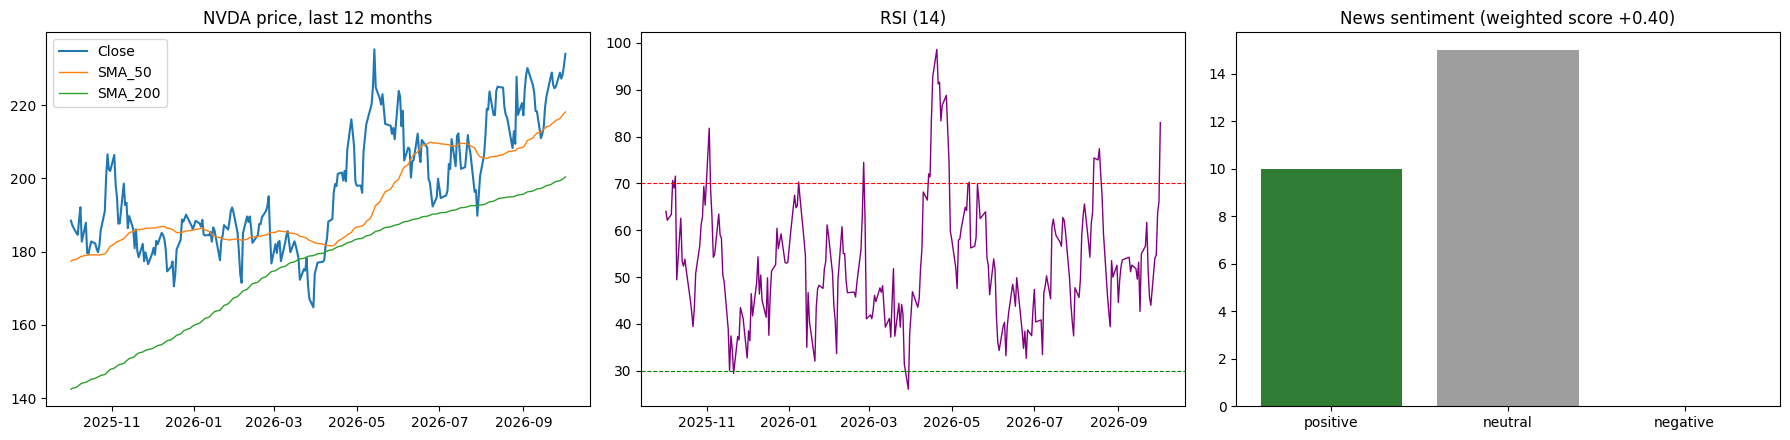

In [41]:
prices = bundle["_frames"]["prices"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

if prices is not None:
    p = prices.tail(252)
    axes[0].plot(p.index, p["Close"], label="Close", lw=1.5)
    for c in ["SMA_50", "SMA_200"]:
        axes[0].plot(p.index, p[c], label=c, lw=1)
    axes[0].set_title(f"{bundle['symbol']} price, last 12 months"); axes[0].legend()

    axes[1].plot(p.index, p["RSI_14"], color="purple", lw=1)
    axes[1].axhline(70, ls="--", c="red", lw=.8); axes[1].axhline(30, ls="--", c="green", lw=.8)
    axes[1].set_title("RSI (14)")

if not arts.empty:
    order = ["positive", "neutral", "negative"]
    counts = arts["sentiment"].value_counts().reindex(order).fillna(0)
    axes[2].bar(counts.index, counts.values, color=["#2e7d32", "#9e9e9e", "#c62828"])
    axes[2].set_title(f"News sentiment (weighted score {bundle['news']['aggregate']['weighted_score']:+.2f})")

plt.tight_layout(); plt.show()

### 13.6 Data-quality checks (input for Student 3's evaluator)

Simple, objective checks on the data layer. Student 3 can fold these into the overall quality score: a report built on missing or stale data should never score high on "accuracy" or "evidence".

In [42]:
# [export] quality_report
def data_quality_report(b: Dict[str, Any]) -> pd.DataFrame:
    checks = []
    req = set(b["pipeline_meta"].get("sources_requested", ALL_SOURCES))
    def add(name, passed, detail="", source=None):
        if source and source not in req:
            return                      # user skipped this source: don't count it against quality
        checks.append({"check": name, "pass": bool(passed), "detail": detail})

    ps = b["market"]["price_summary"]
    T = CONFIG["THRESHOLDS"]
    add("price data present", ps is not None, source="prices")
    prices = b.get("_frames", {}).get("prices")
    if prices is not None:
        add(f"≥ {T['min_price_days']} trading days of prices", len(prices) >= T["min_price_days"],
            f"{len(prices)} days", source="prices")
    if ps:
        age = (datetime.now() - pd.to_datetime(ps["last_date"])).days
        add(f"price data fresh (≤ {T['max_price_age_days']} days)", age <= T["max_price_age_days"], f"{age} days old", source="prices")
    ci = b["fundamentals"]["company_info"] or {}
    core_fields = ["trailingPE", "forwardPE", "profitMargins", "revenueGrowth", "marketCap"]
    n_core = sum(ci.get(k) is not None for k in core_fields)
    add(f"fundamentals complete (≥ {T['min_fundamental_fields']} of 5 core fields)",
        n_core >= T["min_fundamental_fields"], f"{n_core}/5", source="fundamentals")
    add("financial statements present", bool(b["fundamentals"]["key_financials"]), source="fundamentals")
    add("macro data present", bool(b["macro"]), f"{len(b['macro'] or {})} series", source="macro")
    add("SEC filings present", bool(b["filings"]), f"{len(b['filings'] or [])} filings", source="sec")
    n = b["news"]["aggregate"]["n_articles"]
    add(f"≥ {T['min_articles_for_sentiment']} articles for trusted sentiment", n >= T["min_articles_for_sentiment"],
        f"{n} articles", source="news")
    add("≥ 1 trusted publisher", b["news"]["aggregate"].get("trusted_share", 0) > 0,
        f"trusted share {b['news']['aggregate'].get('trusted_share', 0):.0%}", source="news")
    add("live news (not sample)", not b["news"]["used_sample_data"], source="news")
    srcs = {a["article"]["source"] for a in b["news"]["articles"]}
    add(f"≥ {T['min_news_sources']} independent news sources", len(srcs) >= T["min_news_sources"],
        ", ".join(sorted(srcs)), source="news")
    add("LLM used for NLP", b["pipeline_meta"]["llm_enabled"])
    llm_calls = b["pipeline_meta"]["llm_calls"]
    add("LLM failure rate < 10%", llm_calls == 0 or b["pipeline_meta"]["llm_failures"] / llm_calls < 0.1,
        f"{b['pipeline_meta']['llm_failures']}/{llm_calls}")
    # Cross-source consistency: Yahoo revenue vs SEC reported revenue (same fiscal year)
    kf, sec = b["fundamentals"]["key_financials"] or {}, b["fundamentals"]["sec_key_facts"] or {}
    if "Total Revenue" in kf and "Revenues" in sec:
        yv = list(kf["Total Revenue"].values())[0]; sv = sec["Revenues"]["value"]
        diff = abs(yv - sv) / sv
        add("Yahoo vs SEC revenue within 2%", diff < 0.02, f"diff {diff:.1%}")
    # Our sentiment vs Alpha Vantage's
    av = b["external_sentiment"]["alphavantage"]
    if av:
        av_mean = np.mean([a["ticker_sentiment"] for a in av if a["ticker_relevance"] > 0.3] or [0])
        ours = b["news"]["aggregate"]["weighted_score"]
        add("sentiment direction agrees with Alpha Vantage", np.sign(av_mean) == np.sign(ours) or abs(av_mean - ours) < 0.2,
            f"ours {ours:+.2f} vs AV {av_mean:+.2f}")
    df = pd.DataFrame(checks)
    df.attrs["score"] = round(df["pass"].mean(), 2)
    return df

In [43]:
dq = data_quality_report(bundle)
display(dq)
print("Data-layer quality score:", dq.attrs["score"])

,check,pass,detail
0,price data present,True,
1,≥ 20 trading days of prices,True,501 days
2,price data fresh (≤ 5 days),True,1 days old
3,fundamentals complete (≥ 3 of 5 core fields),True,5/5
4,financial statements present,True,
5,macro data present,True,8 series
6,SEC filings present,True,10 filings
7,≥ 3 articles for trusted sentiment,True,25 articles
8,≥ 1 trusted publisher,True,trusted share 88%
9,live news (not sample),True,


Data-layer quality score: 0.86


### 13.6b Automated data-quality commentary

Turns the checks above into plain-English notes you can paste into the report or read in the presentation video.

In [44]:
# [export] quality_commentary
def data_quality_commentary(b: Dict[str, Any], dq: pd.DataFrame) -> List[str]:
    agg, obs = b["news"]["aggregate"], []
    ps = b["market"]["price_summary"]
    if ps:
        obs.append(f"{b['symbol']} last closed at ${ps['last_close']} on {ps['last_date']}, "
                   f"{ps['return_1m']:+.1%} over one month, RSI {ps['rsi_14']}." if ps["return_1m"] is not None
                   else f"{b['symbol']} last closed at ${ps['last_close']} on {ps['last_date']}.")
    if agg["n_articles"]:
        line = (f"News sentiment is {agg['overall_label']} (weighted score {agg['weighted_score']:+.2f}) across "
                f"{agg['n_articles']} articles, {agg['trusted_share']:.0%} from trusted publishers.")
        if agg.get("vader_mean") is not None:
            line += f" The VADER baseline averages {agg['vader_mean']:+.2f}."
        obs.append(line)
        top_events = ", ".join(f"{k} ({v})" for k, v in list(agg["event_counts"].items())[:3])
        obs.append(f"The most common news event types were {top_events}.")
    if agg.get("low_confidence"):
        obs.append(f"Sentiment is LOW CONFIDENCE: fewer than {CONFIG['THRESHOLDS']['min_articles_for_sentiment']} relevant articles.")
    if b["news"]["used_sample_data"]:
        obs.append("⚠️ Live news was unavailable, so labeled SAMPLE articles were used. News findings are not real.")
    failed = dq[~dq["pass"]]
    obs.append("All data-quality checks passed." if failed.empty else
               "Checks that failed: " + "; ".join(f"{r.check} ({r.detail})" if r.detail else r.check
                                                  for r in failed.itertuples()) + ".")
    errs = [k for k, v in b["pipeline_meta"]["tool_status"].items() if v.startswith("error")]
    if errs:
        obs.append(f"{len(errs)} tool(s) returned errors: {', '.join(errs)}. See pipeline_meta.tool_status.")
    g = b["pipeline_meta"].get("gates", {})
    if g:
        fails = sum(v["failed"] for v in g.values()); checks = sum(v["checked"] for v in g.values())
        obs.append(f"Prompt-chain gates ran {checks} checks and caught {fails} problem(s)"
                   + (f": {b['pipeline_meta']['gate_failures'][0]['issues'][0]}" if fails else "."))
    obs.append(f"Overall data-layer quality score: {dq.attrs['score']:.0%}.")
    return obs

In [45]:
print(f"Data-quality commentary for {bundle['symbol']}\n")
for n, line in enumerate(data_quality_commentary(bundle, dq), 1):
    print(textwrap.fill(f"{n}. {line}", 110, subsequent_indent="   "))

Data-quality commentary for NVDA

1. NVDA last closed at $233.95 on 2026-10-02, +4.4% over one month, RSI 83.0.
2. News sentiment is positive (weighted score +0.40) across 25 articles, 88% from trusted publishers. The
   VADER baseline averages +0.20.
3. The most common news event types were other (19), product (4), analyst_rating (1).
4. Checks that failed: ≥ 2 independent news sources (google_rss); LLM used for NLP.
5. 1 tool(s) returned errors: fetch_news_yfinance. See pipeline_meta.tool_status.
6. Prompt-chain gates ran 76 checks and caught 0 problem(s).
7. Overall data-layer quality score: 86%.


### 13.7 Tool specs for Student 2 (function-calling format)

In [46]:
print(json.dumps(get_tool_specs("openai")[:2], indent=2))
print(f"... {len(TOOL_REGISTRY)} tools total. Use get_tool_specs('anthropic') for Claude.")

# Save specs so the orchestrator notebook can load them without re-running this one
with open(os.path.join(CONFIG["OUTPUT_DIR"], "tool_specs.json"), "w") as f:
    json.dump(get_tool_specs("openai"), f, indent=2)

[
  {
    "type": "function",
    "function": {
      "name": "get_price_history",
      "description": "Daily OHLCV price history with SMA20/50/200, RSI14 and 20-day annualized volatility.",
      "parameters": {
        "type": "object",
        "properties": {
          "symbol": {
            "type": "string",
            "description": "Ticker, e.g. NVDA"
          },
          "period": {
            "type": "string",
            "description": "1mo|3mo|6mo|1y|2y|5y"
          }
        },
        "required": [
          "symbol"
        ]
      }
    }
  },
  {
    "type": "function",
    "function": {
      "name": "get_company_info",
      "description": "Company profile, valuation multiples, margins, growth, analyst targets.",
      "parameters": {
        "type": "object",
        "properties": {
          "symbol": {
            "type": "string",
            "description": "Ticker"
          }
        },
        "required": [
          "symbol"
        ]
      }
    }
  }
]

### 13.8 Interactive mode (optional): type a ticker, click Run

A small UI for the demo. Type a ticker, pick sources, click **Fetch data**. It validates the ticker, runs the pipeline, and prints the headline results. The full result lands in `bundle`, so every cell above can be rerun on the new ticker.

Without the widget, call `fetch_and_summarize("AAPL")` in any cell.

In [47]:
import ipywidgets as w
from IPython.display import clear_output

ticker_box = w.Text(value=SYMBOL, description="Ticker:", placeholder="e.g. AAPL", layout=w.Layout(width="220px"))
peers_box = w.Text(value=PEERS, description="Peers:", placeholder="AMD, INTC (optional)", layout=w.Layout(width="320px"))
lookback = w.IntSlider(value=NEWS_LOOKBACK_DAYS, min=3, max=30, description="News days:")
source_boxes = {s: w.Checkbox(value=True, description=s, indent=False, layout=w.Layout(width="120px"))
                for s in sorted(ALL_SOURCES)}
run_btn = w.Button(description="Fetch data", button_style="primary", icon="search")
out = w.Output()

def fetch_and_summarize(ticker: str, peers_text: str = "", sources: Optional[set] = None,
                        lookback_days: int = 14) -> Optional[Dict[str, Any]]:
    # Validate -> run pipeline -> print a short summary. Usable without the widget too.
    global bundle, SYMBOL
    chk = validate_ticker(ticker)
    if chk["valid"] is False:
        hint = f" Did you mean: {', '.join(chk['suggestions'])}?" if chk["suggestions"] else ""
        print("❌", chk["note"] + hint)
        return None
    SYMBOL = chk["symbol"]
    print(f"Running pipeline for {SYMBOL} ({chk['company_name'] or 'name unknown'})...")
    CONFIG["NEWS_LOOKBACK_DAYS"] = lookback_days
    bundle = run_data_pipeline(SYMBOL, peers=parse_peers(peers_text), sources=sources, lookback_days=lookback_days)
    for k, v in bundle["pipeline_meta"]["tool_status"].items():
        print(f"  {'✅' if v == 'ok' else '⏭️' if v in ('skipped', 'no key') else '❌'} {k}")
    ps = bundle["market"]["price_summary"]
    if ps:
        r1m = f"{ps['return_1m']:+.1%}" if ps["return_1m"] is not None else "n/a"
        print(f"\nLast close ${ps['last_close']} ({ps['last_date']}) | 1m {r1m} | RSI {ps['rsi_14']}")
    agg = bundle["news"]["aggregate"]
    print(f"News: {agg['n_articles']} articles, sentiment {agg['weighted_score']:+.2f} ({agg['overall_label']})")
    print("Headline:", bundle["news"]["digest"]["headline"])
    print(f"\nData-layer quality score: {data_quality_report(bundle).attrs['score']}")
    print("Rerun Step 13.1–13.6 to see tables and charts for this ticker.")
    return bundle


def on_run(_):
    with out:
        clear_output()
        try:
            fetch_and_summarize(ticker_box.value, peers_box.value,
                                {s for s, cb in source_boxes.items() if cb.value}, lookback.value)
        except Exception as e:
            print(f"❌ {type(e).__name__}: {e}")

run_btn.on_click(on_run)
display(w.VBox([w.HBox([ticker_box, peers_box]), lookback, w.HBox(list(source_boxes.values())), run_btn, out]))

### 13.9 Export the pipeline as a Python module for Student 2

Notebooks can't import functions from each other. This cell collects every cell marked `# [export]` (all function and config cells, none of the demo cells) and writes them to **`student1_pipeline.py`**. Student 2 imports that file and gets the real functions, not just the JSON specs.

It reads IPython's execution history (`In`), so **run all cells above first**. If a cell was rerun, the latest version wins. The last part re-imports the file in a fresh Python process to prove it works on its own.

**How Student 2 uses it (in their own Colab notebook):**
```python

import student1_pipeline as s1

s1.validate_ticker("NVDA")                       # check user input
specs  = s1.get_tool_specs("openai")             # give these to the planner LLM
result = s1.call_tool("get_price_history", symbol="NVDA", period="6mo")   # execute a tool call
bundle = s1.run_data_pipeline("NVDA", sources={"news", "prices"})         # or the whole pipeline
s1.call_llm("...", step="planner")               # shared LLM client + LLM_LOG
```

In [48]:
import subprocess, sys

EXPORT_MARK = "# [export]"
MODULE_PATH = "student1_pipeline.py"
SHARE_DIR = ""   # optional, e.g. "/content/drive/MyDrive/AAI520_team" after mounting Drive

blocks = {}                                         # marker line -> latest source, in first-seen order
for src in get_ipython().user_ns["In"]:
    if src.lstrip().startswith(EXPORT_MARK):
        key = src.lstrip().splitlines()[0].strip()
        blocks[key] = src

Q = chr(34) * 3   # triple quote, written this way so the builder's string isn't closed
header = "\n".join([
    Q,
    "student1_pipeline.py - Data & NLP pipeline (Student 1), auto-exported from Notebook 1.",
    "Do not edit by hand: change the notebook and re-run the export cell.",
    "",
    "Main entry points:",
    "  validate_ticker(symbol)                 -> dict (valid / suggestions)",
    "  run_data_pipeline(symbol, peers, sources, lookback_days) -> DataBundle dict (+ JSON/CSV files)",
    "  call_tool(name, **kwargs)               -> tool_result envelope, with retries",
    "  get_tool_specs('openai' | 'anthropic')  -> function-calling specs for the planner",
    "  call_llm(prompt, ...)                   -> shared LLM client (logs to LLM_LOG)",
    "  data_quality_report(bundle), data_quality_commentary(bundle, dq)",
    Q, "", ""])
with open(MODULE_PATH, "w") as f:
    f.write(header + "\n\n".join(b for b in blocks.values()) + "\n")
print(f"Wrote {MODULE_PATH}: {len(blocks)} cells, {sum(len(b.splitlines()) for b in blocks.values())} lines")

# Prove the module works on its own (fresh interpreter, no notebook state)
REQUIRED = ["validate_ticker", "run_data_pipeline", "call_tool", "get_tool_specs", "call_llm",
            "TOOL_REGISTRY", "TOOL_FALLBACKS", "data_quality_report", "data_quality_commentary", "GATE_LOG"]
test = subprocess.run([sys.executable, "-c",
    f"import {MODULE_PATH[:-3]} as m; miss=[n for n in {REQUIRED!r} if not hasattr(m, n)]; "
    f"print('MISSING:', miss) if miss else print('import OK -', len(m.TOOL_REGISTRY), 'tools,', len(m.get_tool_specs()), 'specs')"],
    capture_output=True, text=True)
print(test.stdout.strip().splitlines()[-1] if test.stdout.strip() else "", test.stderr.strip()[-800:])

if SHARE_DIR:
    import shutil; os.makedirs(SHARE_DIR, exist_ok=True)
    for p in [MODULE_PATH, os.path.join(CONFIG["OUTPUT_DIR"], "tool_specs.json")]:
        shutil.copy(p, SHARE_DIR)
    print("Copied to", SHARE_DIR)

Wrote student1_pipeline.py: 19 cells, 1349 lines
import OK - 12 tools, 12 specs 


## Step 14 - Summary and next steps

### What Student 1 delivered

| Requirement | Where | Notes |
|---|---|---|
| **News retrieval** | Step 5.2 | Yahoo Finance + Google News RSS (keyless) + NewsAPI (optional) + Alpha Vantage (optional) |
| **Preprocessing** | Step 6 | HTML cleanup, exact + near-duplicate removal, recency window, relevance scoring |
| **Classification** | Step 7 | Shareholder-perspective sentiment (−1..+1) and 12 event types; LLM with rule fallback |
| **Extraction** | Step 8 | Entities, key figures, events, risks, opportunities as JSON |
| **Summarization** | Step 9 | Per-article summary + cross-article digest with `[id]` citations |
| **Prompt chaining** | Step 10 | classify → extract → summarize → digest; each step consumes the previous output; 4 programmatic gates (grounding checks) between steps; traced |
| **Python module for Student 2** | Step 13.9 | `student1_pipeline.py` auto-exported from this notebook and import-tested |
| **Data tools** | Step 5 | 12 tools across market, fundamentals, news, macro (FRED), filings (SEC EDGAR) |
| **Tool registry** | Step 11 | Function-calling specs + retry + fallback chains |
| **User ticker input** | Step 2.1, Step 5.6, Step 13.8 | Colab form + click-to-run widget; ticker validated against Yahoo + SEC with "did you mean" suggestions |
| **Single entry point** | Step 12 | `run_data_pipeline(symbol, peers, sources, lookback_days)` → `DataBundle` JSON |
| **Data quality checks** | Step 13.6 | Freshness, coverage, source diversity, Yahoo-vs-SEC and ours-vs-Alpha-Vantage cross-checks |

### Files this notebook produces (`outputs/`)

| File | Contents | Used by |
|---|---|---|
| `{SYMBOL}_data_bundle.json` | Everything: market, fundamentals, filings, macro, processed news, digest, metadata | **Student 2 (agents)**, Student 3 (report) |
| `{SYMBOL}_news_processed.csv` | One row per article: sentiment, VADER baseline, event type, summary, risks | News Analyst, evaluator |
| `{SYMBOL}_prices.csv` | Daily OHLCV + SMA / RSI / volatility | Market Analyst, charts |
| `{SYMBOL}_fundamentals.csv` | Valuation, margins, growth, analyst targets | Earnings Analyst |
| `macro_snapshot.csv` | Latest FRED values + 1-year change | Market Analyst |
| `tool_specs.json` | Function-calling specs for every tool | **Student 2 (planner)** |
| `student1_pipeline.py` | All pipeline functions as an importable module | **Student 2 (imports it)** |

**Next step:** Student 2's Notebook 2 does `import student1_pipeline as s1`, passes `s1.get_tool_specs()` to the planner, and executes its choices with `s1.call_tool()` (or the whole `s1.run_data_pipeline()`).

### Hand-off to Student 2 (Agent & Orchestration)

0. **User input.** The planner should take the ticker from the user, call `validate_ticker()` first, and stop with the suggestions if `valid is False`. The `sources=` argument lets the planner skip tool groups it doesn't need.
1. **Planner → tools.** Pass `get_tool_specs("openai")` (or `"anthropic"`) to the planner LLM so it can pick tools dynamically. Execute with `call_tool(name, **args)`. It already retries and never raises.
2. **Fallback.** On `result["ok"] == False`, walk `TOOL_FALLBACKS[category]`. Today only news has a chain; add more if you need them.
3. **Router.** Route bundle sections to specialists: `fundamentals` + `filings` → Earnings Analyst, `news` → News Analyst, `market` + `macro` → Market Analyst.
4. **Memory.** Store `news.digest.headline`, `news.aggregate`, and `pipeline_meta.tool_status` errors per run under the symbol key. That fills `previous_conclusions` and `issues_encountered` in the memory JSON from the diagram.
5. **Reuse `call_llm`** so all LLM usage lands in one `LLM_LOG`.

### Hand-off to Student 3 (Analysis & Quality)

1. **Report inputs.** Everything the report needs is in the bundle. `sources` gives the citation list; digest text already cites `[article_id]`.
2. **Hallucination metric.** `pipeline_meta.gates` gives checked/failed counts per gate, `pipeline_meta.gate_failures` lists what was caught. Gate 2 and 3 failure rates measure how often the LLM invented numbers.
3. **Evaluator inputs.** `data_quality_report(bundle)` gives an objective data-layer score. Use it as a floor for "accuracy/evidence". `ProcessedArticle.method` tells you which articles were LLM vs rule-classified (lower confidence).
4. **Optimizer loop.** If the evaluator flags thin news coverage, the optimizer can re-call `run_data_pipeline` with a longer `NEWS_LOOKBACK_DAYS` or lower `min_relevance`.
5. **Sentiment validation.** Ours vs Alpha Vantage is a ready-made quality metric for the write-up.

### Known limitations (put these in the final report)

- **Yahoo rate limits** on Colab's shared IPs. If tools fail, wait a minute and rerun. The sample fallback is labeled and must not be presented as real analysis.
- **Headline-level NLP.** Yahoo and Google RSS give titles and snippets, not full article text. Full-text scraping was left out (paywalls, terms of service).
- **Rule-based fallback** sentiment is crude. Run the final demo with an LLM key.
- **SEC EDGAR** only covers US filers; foreign tickers return `ok=False`.
- **Relevance aliases** are hand-coded for 4 tickers in `COMPANY_ALIASES`. Other tickers rely on symbol + company name.

### Suggested next steps for the team

1. Agree on the `DataBundle` schema now (Step 12) before Students 2 and 3 build against it.
2. Student 2: wrap `run_data_pipeline` sections as separate agent actions so the planner can skip unneeded tools (e.g. no peers for a quick news check).
3. Student 3: write the evaluator rubric against concrete bundle fields (completeness = which sections are non-null, evidence = citations per claim).
4. Merge the three notebooks into one final submission notebook with this one as Part 1.